# CUADERNO 2: EDA (Análisis Exploratorio de Datos)
## Visualización y Análisis Estadístico de Datos Educativos

**Objetivo:** Comprender patrones, distribuciones y relaciones entre variables académicas y demográficas.

**Metodología:** CRISP-ML (Fase de Exploración y Verificación de Datos).

## Paso 1: Configuración y Carga de Librerías

En esta sección, se instalan y cargan las librerías necesarias para el análisis exploratorio de datos (EDA), incluyendo `pandas` para manipulación de datos, `numpy` para operaciones numéricas, `matplotlib` y `seaborn` para visualización, y `warnings` para gestionar mensajes de advertencia. También se configuran los parámetros globales para los gráficos, como el tamaño de las figuras y el estilo visual, para asegurar una presentación consistente y legible.

In [9]:
# Instalacion de dependencias (solo en Colab)
# !pip install pandas numpy matplotlib seaborn scikit-learn plotly

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

# Configuracion de graficos
plt.rcParams['figure.figsize'] = (14, 6)
plt.rcParams['font.size'] = 12
sns.set_style('whitegrid')
sns.set_palette('Set2')

print('Librerias cargadas exitosamente.')

Librerias cargadas exitosamente.


## Paso 2: Carga de Datos Limpios.

Esta sección se encarga de cargar los datasets limpios que fueron generados en la fase de ETL (Extracción, Transformación y Carga) del proyecto. Se cargan tres versiones del dataset, cada una destinada a un tipo específico de modelado:

*   `df_lr`: Dataset para modelos de Regresión Lineal.
*   `df_log`: Dataset para modelos de Regresión Logística.
*   `df_dt`: Dataset para modelos de Árboles de Decisión.

La salida muestra las dimensiones (número de filas y columnas) de cada DataFrame, confirmando que los datos se han cargado correctamente y proporcionando una visión inicial del volumen de información con el que se trabajará.

In [10]:
# En Colab:
# from google.colab import drive
# drive.mount('/content/drive')
# df = pd.read_csv('/content/drive/MyDrive/ProyectoML/dataset_regresion_lineal.csv')

# Local:
df_lr = pd.read_csv('dataset_regresion_lineal.csv')
df_log = pd.read_csv('dataset_regresion_logistica.csv')
df_dt = pd.read_csv('dataset_arboles_decision.csv')

print(f'Dataset RL: {df_lr.shape}')
print(f'Dataset RLog: {df_log.shape}')
print(f'Dataset AD: {df_dt.shape}')

Dataset RL: (5341, 23)
Dataset RLog: (5341, 25)
Dataset AD: (5341, 27)


## Paso 3: Vista General de los Datos

Esta sección proporciona una visión preliminar de la estructura y el contenido de los datasets, lo cual es fundamental para comprender las variables disponibles y su estado.

### 3.1 Cabecera y estadísticas básicas

Se examinan las primeras filas del DataFrame (`df_lr.head(10)`) para entender la estructura de las columnas y el tipo de valores que contienen. Luego, `df_lr.info()` ofrece un resumen completo de las columnas, incluyendo los tipos de datos, la cantidad de valores no nulos y el uso de memoria, lo que permite identificar rápidamente la presencia de valores ausentes y los tipos de datos incorrectos. Finalmente, `df_lr.describe().T` presenta estadísticas descriptivas clave (media, desviación estándar, mínimos, máximos, cuartiles) para todas las variables numéricas, proporcionando una comprensión rápida de la distribución y el rango de cada característica.

In [11]:
# 3.1 Cabecera del dataset
df_lr.head(10)

,matricula,ano,grado,grupo,cohorte,promedio_nota,intensidad_total_semanal,cantidad_asignaturas,total_faltas,porc_inasistencia,...,nota_maxima,nota_std,prom_1.,prom_10.,prom_2.,prom_3.,prom_5.,prom_6.,prom_7.,prom_9.
0,1,2015,11,110100,2015-11,3.603529,150,17,14,9.333333,...,5.0,0.506493,3.57,3.44,3.30,3.680000,3.193333,3.713333,NaN,4.106667
1,2,2015,11,110100,2015-11,3.602353,150,17,5,3.333333,...,5.0,0.540717,3.45,3.32,3.52,3.600000,3.126667,4.080000,NaN,3.853333
2,3,2015,10,100100,2015-10,2.369412,150,17,65,43.333333,...,5.0,1.058078,2.53,2.24,2.14,2.086667,1.960000,3.060000,NaN,2.460000
3,4,2015,11,110200,2015-11,3.234118,150,17,17,11.333333,...,5.0,0.484412,3.10,3.40,3.10,3.140000,3.020000,3.333333,NaN,3.566667
4,5,2015,11,110100,2015-11,3.335294,150,17,11,7.333333,...,5.0,0.657322,3.24,3.22,3.42,3.266667,3.146667,3.073333,NaN,3.900000
5,6,2015,10,100200,2015-10,3.190588,150,17,20,13.333333,...,4.9,0.701635,3.18,3.32,3.23,2.586667,2.886667,3.673333,NaN,3.553333
6,7,2015,11,110100,2015-11,3.711765,150,17,44,29.333333,...,5.0,0.598095,3.64,3.60,4.11,3.426667,3.773333,3.806667,NaN,3.660000
7,8,2015,10,100100,2015-10,2.983529,150,17,41,27.333333,...,5.0,0.846118,3.31,3.02,2.29,2.940000,2.873333,2.893333,NaN,3.460000
8,9,2015,11,110100,2015-11,3.287059,150,17,23,15.333333,...,4.7,0.457422,3.03,3.24,3.28,3.300000,3.040000,3.200000,NaN,3.800000
9,10,2015,10,100100,2015-10,2.030588,150,17,59,39.333333,...,4.0,1.054697,2.16,2.02,1.93,1.333333,1.853333,2.693333,NaN,2.226667


In [12]:
# Informacion general
df_lr.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5341 entries, 0 to 5340
Data columns (total 23 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   matricula                 5341 non-null   int64  
 1   ano                       5341 non-null   int64  
 2   grado                     5341 non-null   int64  
 3   grupo                     5341 non-null   int64  
 4   cohorte                   5341 non-null   object 
 5   promedio_nota             5341 non-null   float64
 6   intensidad_total_semanal  5341 non-null   int64  
 7   cantidad_asignaturas      5341 non-null   int64  
 8   total_faltas              5341 non-null   int64  
 9   porc_inasistencia         5341 non-null   float64
 10  materias_perdidas         5341 non-null   int64  
 11  total_refuerzos           5341 non-null   int64  
 12  nota_minima               5341 non-null   float64
 13  nota_maxima               5341 non-null   float64
 14  nota_std

In [13]:
# Estadisticas descriptivas
df_lr.describe().T

,count,mean,std,min,25%,50%,75%,max
matricula,5341.0,1008.209137,632.266237,1.0,453.000000,949.000000,1534.000000,2314.000000
ano,5341.0,2018.960307,2.591891,2015.0,2017.000000,2019.000000,2021.000000,2023.000000
grado,5341.0,8.123385,1.690782,6.0,7.000000,8.000000,10.000000,11.000000
grupo,5341.0,81174.059352,17483.951034,3.0,70100.000000,80200.000000,100100.000000,110200.000000
promedio_nota,5341.0,3.174741,0.936555,0.0,3.048235,3.448000,3.733846,4.645333
intensidad_total_semanal,5341.0,163.785808,16.990783,75.0,150.000000,175.000000,175.000000,190.000000
cantidad_asignaturas,5341.0,13.340386,2.962474,1.0,10.000000,13.000000,16.000000,18.000000
total_faltas,5341.0,28.294327,39.403857,0.0,6.000000,15.000000,35.000000,436.000000
porc_inasistencia,5341.0,17.686792,25.909309,0.0,3.428571,9.714286,21.875000,242.222222
materias_perdidas,5341.0,13.319041,19.770236,0.0,1.000000,3.000000,18.000000,90.000000


### 3.2 Valores nulos

Aquí se identifican y se presentan las columnas que contienen valores nulos. La salida en la celda de código a continuación muestra que varias columnas (`prom_1.`, `prom_10.`, `prom_2.`, `prom_3.`, `prom_5.`, `prom_6.`, `prom_7.`, `prom_9.`) tienen valores faltantes. Estas columnas representan promedios de notas en diferentes áreas del saber. La presencia de valores nulos, especialmente en `prom_10.` (3369 nulos) y `prom_7.` (2782 nulos), sugiere que no todos los estudiantes tienen calificaciones registradas en todas las áreas, lo cual es común en sistemas educativos donde algunas materias son electivas o no se dictan en todos los grados/cohortes. Esta información es crucial para las fases posteriores de preprocesamiento de datos, donde se deberá decidir cómo manejar estos valores (imputación, eliminación, etc.).

In [14]:
# Valores nulos encontrados

In [15]:
print('Valores nulos encontrados:')
print(df_lr.isnull().sum()[df_lr.isnull().sum() > 0])

Valores nulos encontrados:
prom_1.       17
prom_10.    3369
prom_2.       17
prom_3.       17
prom_5.       17
prom_6.       17
prom_7.     2782
prom_9.       17
dtype: int64


## Paso 4: Análisis Univariado

Esta sección se enfoca en el análisis individual de cada variable, proporcionando una comprensión profunda de sus distribuciones, tendencias y características clave.

### 4.1 Distribución de la variable target (promedio_nota)

Se examina la distribución de la variable `promedio_nota` mediante un histograma, un boxplot y un violin plot. La media del `promedio_nota` es de aproximadamente 3.17, lo que indica que, en general, los estudiantes están por encima del límite mínimo de aprobación (3.0). El histograma muestra una clara concentración de notas entre 3.0 y 4.0, con una cola hacia notas más bajas y un pico en 0.0, lo que sugiere la presencia de estudiantes con muy bajo rendimiento o que no han completado todas las evaluaciones. El boxplot y el violin plot confirman esta distribución, resaltando la densidad de notas alrededor de la media y la presencia de valores atípicos (outliers) en ambos extremos, especialmente en el rango bajo. Esto es crucial para entender el rendimiento general y la variabilidad en las notas.

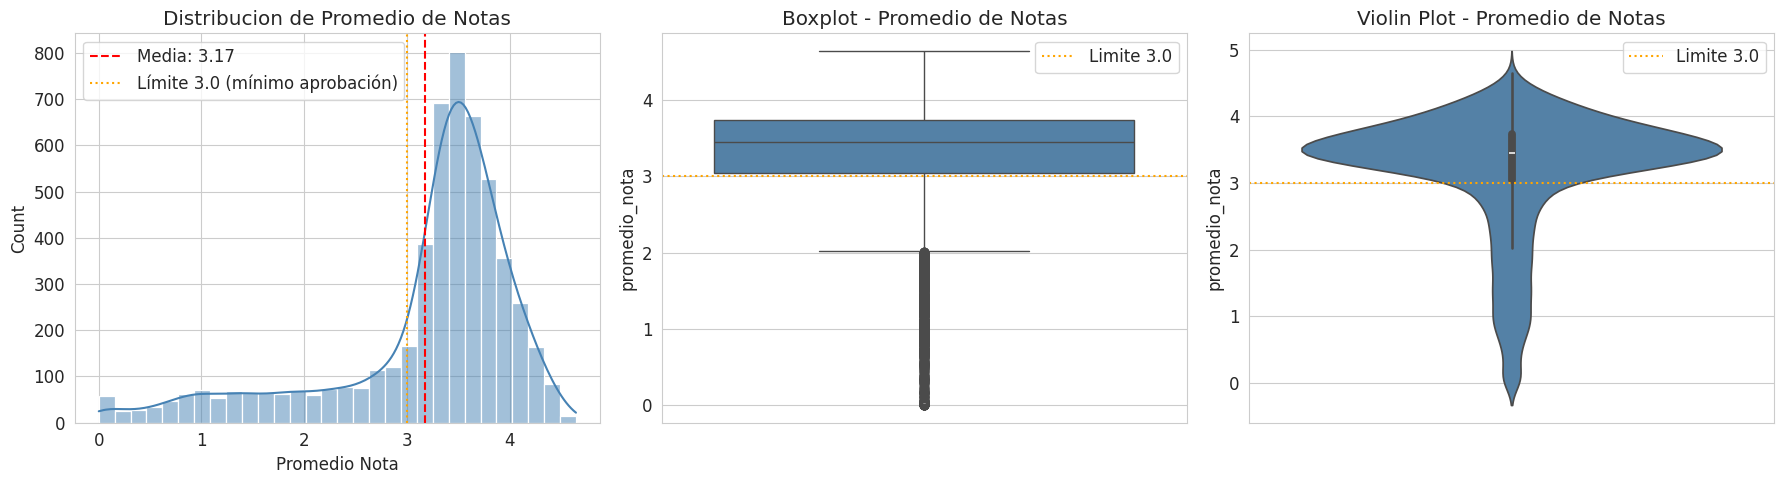

Estadisticas de promedio_nota:
count    5341.000000
mean        3.174741
std         0.936555
min         0.000000
25%         3.048235
50%         3.448000
75%         3.733846
max         4.645333
Name: promedio_nota, dtype: float64


In [16]:
# 4.1 Distribucion del promedio de notas
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# Histograma
sns.histplot(df_lr['promedio_nota'], bins=30, kde=True, ax=axes[0], color='steelblue')
axes[0].axvline(df_lr['promedio_nota'].mean(), color='red', linestyle='--', label=f'Media: {df_lr["promedio_nota"].mean():.2f}')
axes[0].axvline(3.0, color='orange', linestyle=':', label='Límite 3.0 (mínimo aprobación)')
axes[0].set_title('Distribucion de Promedio de Notas')
axes[0].set_xlabel('Promedio Nota')
axes[0].legend()

# Boxplot
sns.boxplot(y=df_lr['promedio_nota'], ax=axes[1], color='steelblue')
axes[1].axhline(3.0, color='orange', linestyle=':', label='Limite 3.0')
axes[1].set_title('Boxplot - Promedio de Notas')
axes[1].legend()

# Violin plot
sns.violinplot(y=df_lr['promedio_nota'], ax=axes[2], color='steelblue')
axes[2].axhline(3.0, color='orange', linestyle=':', label='Limite 3.0')
axes[2].set_title('Violin Plot - Promedio de Notas')
axes[2].legend()

plt.tight_layout()
plt.show()

print(f'Estadisticas de promedio_nota:')
print(df_lr['promedio_nota'].describe())

### 4.2 Distribución de la variable target binaria (promovido_bin)

La variable `promovido_bin` (0 para 'No Promovido', 1 para 'Promovido') representa el objetivo principal del modelo de clasificación. Los gráficos de barras y de pastel muestran un desequilibrio de clases significativo: el 74.0% de los estudiantes son promovidos, mientras que el 26.0% no lo son. Esta distribución es importante porque un modelo predictivo podría sesgarse hacia la clase mayoritaria (promovidos), dificultando la identificación precisa de los estudiantes en riesgo de no promoción. Será necesario considerar técnicas de balanceo de clases durante la fase de modelado para abordar este problema.

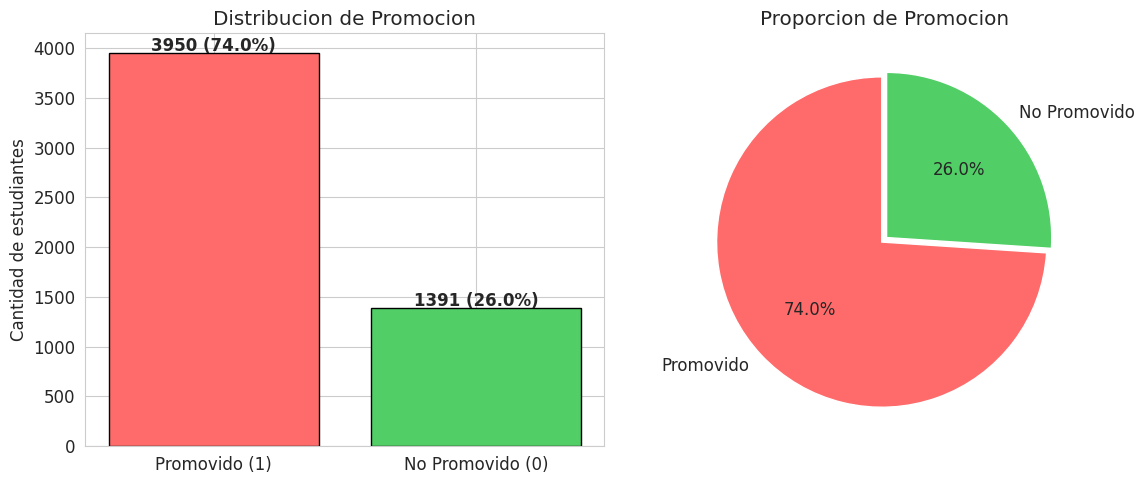


Total estudiantes-año analizados: 5341
Promovidos: 3950 (74.0%)
No Promovidos: 1391 (26.0%)


In [17]:
# 4.2 Distribucion de promovido (target binario)
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# Conteo
counts = df_log['promovido_bin'].value_counts()
# The user wants red for 'Promovido (1)' and green for 'No Promovido (0)'
# Since counts.values is [count_promoted, count_not_promoted],
# colors[0] should be red (for promoted) and colors[1] should be green (for not promoted).
colors = ['#ff6b6b', '#51cf66']
axes[0].bar(['Promovido (1)', 'No Promovido (0)'], counts.values, color=colors, edgecolor='black')
for i, v in enumerate(counts.values):
    axes[0].text(i, v + 20, f'{v} ({v/counts.sum()*100:.1f}%)', ha='center', fontweight='bold')
axes[0].set_title('Distribucion de Promocion')
axes[0].set_ylabel('Cantidad de estudiantes')

# Pie
axes[1].pie(counts.values, labels=['Promovido', 'No Promovido'], autopct='%1.1f%%',
            colors=colors, startangle=90, explode=(0.02, 0.02))
axes[1].set_title('Proporcion de Promocion')

plt.tight_layout()
plt.show()

print(f'\nTotal estudiantes-año analizados: {len(df_log)}')
print(f'Promovidos: {counts.get(1, 0)} ({counts.get(1, 0)/counts.sum()*100:.1f}%)')
print(f'No Promovidos: {counts.get(0, 0)} ({counts.get(0, 0)/counts.sum()*100:.1f}%)')

### 4.3 Distribución por Grado

Este análisis explora cómo varían la cantidad de estudiantes, el `promedio_nota` y la tasa de promoción a través de los diferentes grados (6 a 11). El primer gráfico de barras (`Estudiantes por Grado`) muestra la distribución de estudiantes por grado, lo cual es útil para identificar el tamaño de cada cohorte por nivel. El segundo gráfico de barras (`Promedio de Notas por Grado`) revela que los grados superiores (10 y 11) tienden a tener promedios de notas más altos, mientras que los grados inferiores (6, 7 y 8) presentan promedios más cercanos al límite de 3.0. La tabla `Tasa de Promocion por grado` confirma esta tendencia: los grados 6, 7 y 8 tienen las tasas de promoción más bajas (entre 65.7% y 68.1%), mientras que el grado 11 destaca con una tasa de promoción del 94.5%. Esto sugiere que los estudiantes en los primeros años de secundaria enfrentan mayores desafíos y que los que llegan a los grados finales tienen un perfil académico más consolidado.

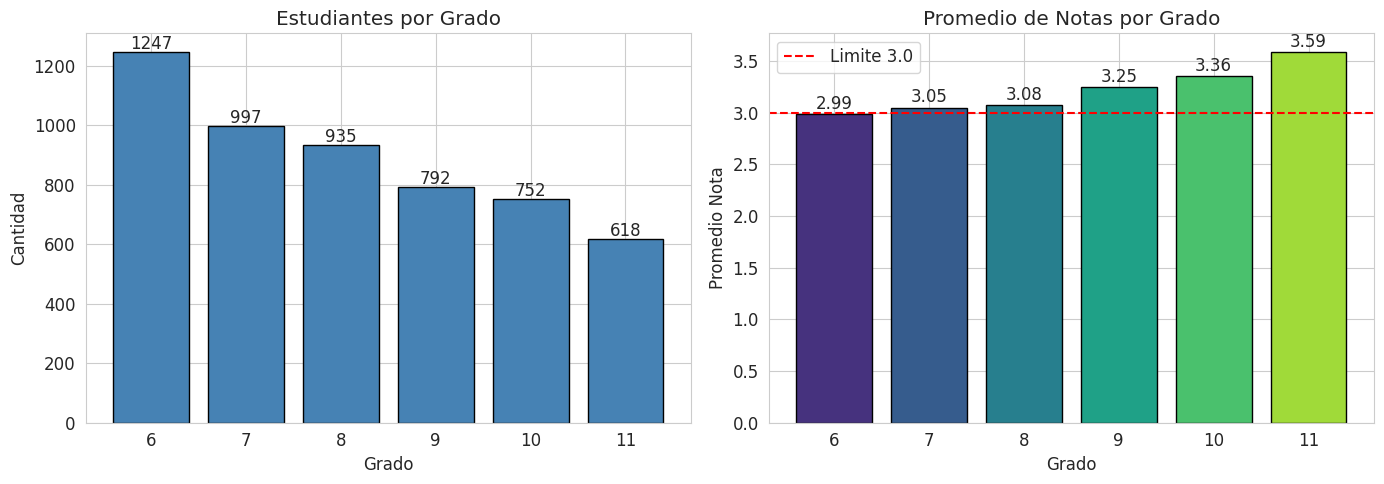


Tasa de promocion por grado:
       Tasa Promocion (%)
grado                    
6                    65.7
7                    67.5
8                    68.1
9                    78.4
10                   81.9
11                   94.5


In [18]:
# 4.3 Analisis por grado
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Cantidad por grado
grado_counts = df_log['grado'].value_counts().sort_index()
axes[0].bar(grado_counts.index, grado_counts.values, color='steelblue', edgecolor='black')
axes[0].set_title('Estudiantes por Grado')
axes[0].set_xlabel('Grado')
axes[0].set_ylabel('Cantidad')
for i, v in enumerate(grado_counts.values):
    axes[0].text(grado_counts.index[i], v + 10, str(v), ha='center')

# Promedio nota por grado
grado_prom = df_log.groupby('grado')['promedio_nota'].mean()
axes[1].bar(grado_prom.index, grado_prom.values, color=sns.color_palette('viridis', 6), edgecolor='black')
axes[1].axhline(3.0, color='red', linestyle='--', label='Limite 3.0')
axes[1].set_title('Promedio de Notas por Grado')
axes[1].set_xlabel('Grado')
axes[1].set_ylabel('Promedio Nota')
axes[1].legend()
for i, v in enumerate(grado_prom.values):
    axes[1].text(grado_prom.index[i], v + 0.05, f'{v:.2f}', ha='center')

plt.tight_layout()
plt.show()

# Tasa de promocion por grado
print('\nTasa de promocion por grado:')
grado_promov = df_log.groupby('grado')['promovido_bin'].mean() * 100
print(grado_promov.to_frame('Tasa Promocion (%)').round(1))

### 4.4 Evolución Anual

Este análisis examina las tendencias del `promedio_nota`, la tasa de promoción y la cantidad de estudiantes a lo largo de los años. Los gráficos de línea muestran que tanto el `promedio_nota` como la tasa de promoción experimentaron un incremento notable en los años 2020 y 2021. Este fenómeno podría estar relacionado con las adaptaciones pedagógicas y de evaluación implementadas durante la pandemia de COVID-19, que pudieron haber influido en el rendimiento académico y las políticas de promoción. El gráfico de barras de `Estudiantes por Año` muestra una distribución relativamente consistente de estudiantes a lo largo de los años, aunque con ligeras variaciones, lo que indica que el tamaño de la población estudiantil se mantuvo estable.

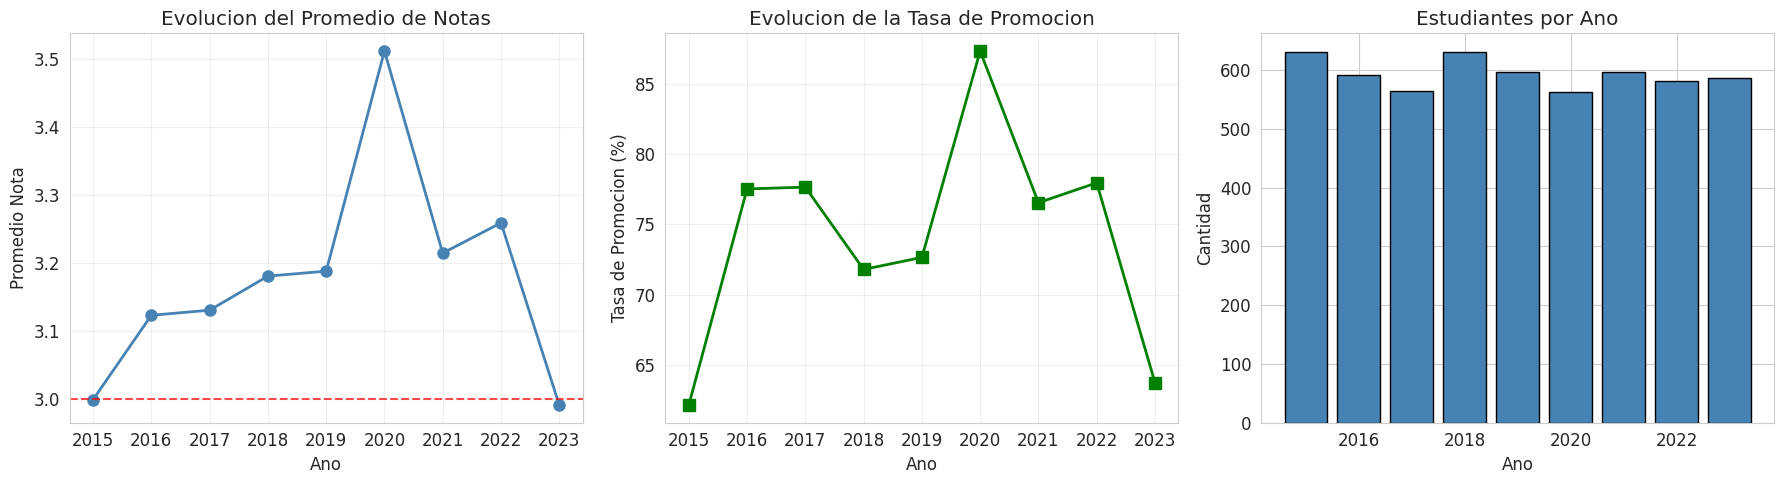

In [19]:
# 4.4 Tendencia a traves de los anos
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# Promedio por ano
ano_prom = df_log.groupby('ano')['promedio_nota'].mean()
axes[0].plot(ano_prom.index, ano_prom.values, marker='o', linewidth=2, markersize=8, color='steelblue')
axes[0].axhline(3.0, color='red', linestyle='--', alpha=0.7)
axes[0].set_title('Evolucion del Promedio de Notas')
axes[0].set_xlabel('Ano')
axes[0].set_ylabel('Promedio Nota')
axes[0].grid(True, alpha=0.3)

# Tasa promocion por ano
ano_promov = df_log.groupby('ano')['promovido_bin'].mean() * 100
axes[1].plot(ano_promov.index, ano_promov.values, marker='s', linewidth=2, markersize=8, color='green')
axes[1].set_title('Evolucion de la Tasa de Promocion')
axes[1].set_xlabel('Ano')
axes[1].set_ylabel('Tasa de Promocion (%)')
axes[1].grid(True, alpha=0.3)

# Estudiantes por ano
ano_count = df_log['ano'].value_counts().sort_index()
axes[2].bar(ano_count.index, ano_count.values, color='steelblue', edgecolor='black')
axes[2].set_title('Estudiantes por Ano')
axes[2].set_xlabel('Ano')
axes[2].set_ylabel('Cantidad')

plt.tight_layout()
plt.show()

## Paso 5: Análisis Bivariado y Correlaciones

Esta sección explora las relaciones entre pares de variables, centrándose en cómo se correlacionan las características entre sí y, en particular, con la variable objetivo `promedio_nota`.

### 5.1 Matriz de correlación

La matriz de correlación se visualiza mediante un mapa de calor (heatmap), que permite identificar rápidamente las relaciones lineales entre todas las variables numéricas del dataset. Los valores cercanos a 1 indican una fuerte correlación positiva, los cercanos a -1 una fuerte correlación negativa, y los cercanos a 0 una correlación débil o nula. Esta visualización es crucial para entender la estructura de los datos, identificar posibles multicolinealidades (variables altamente correlacionadas entre sí) y preseleccionar características para el modelado.

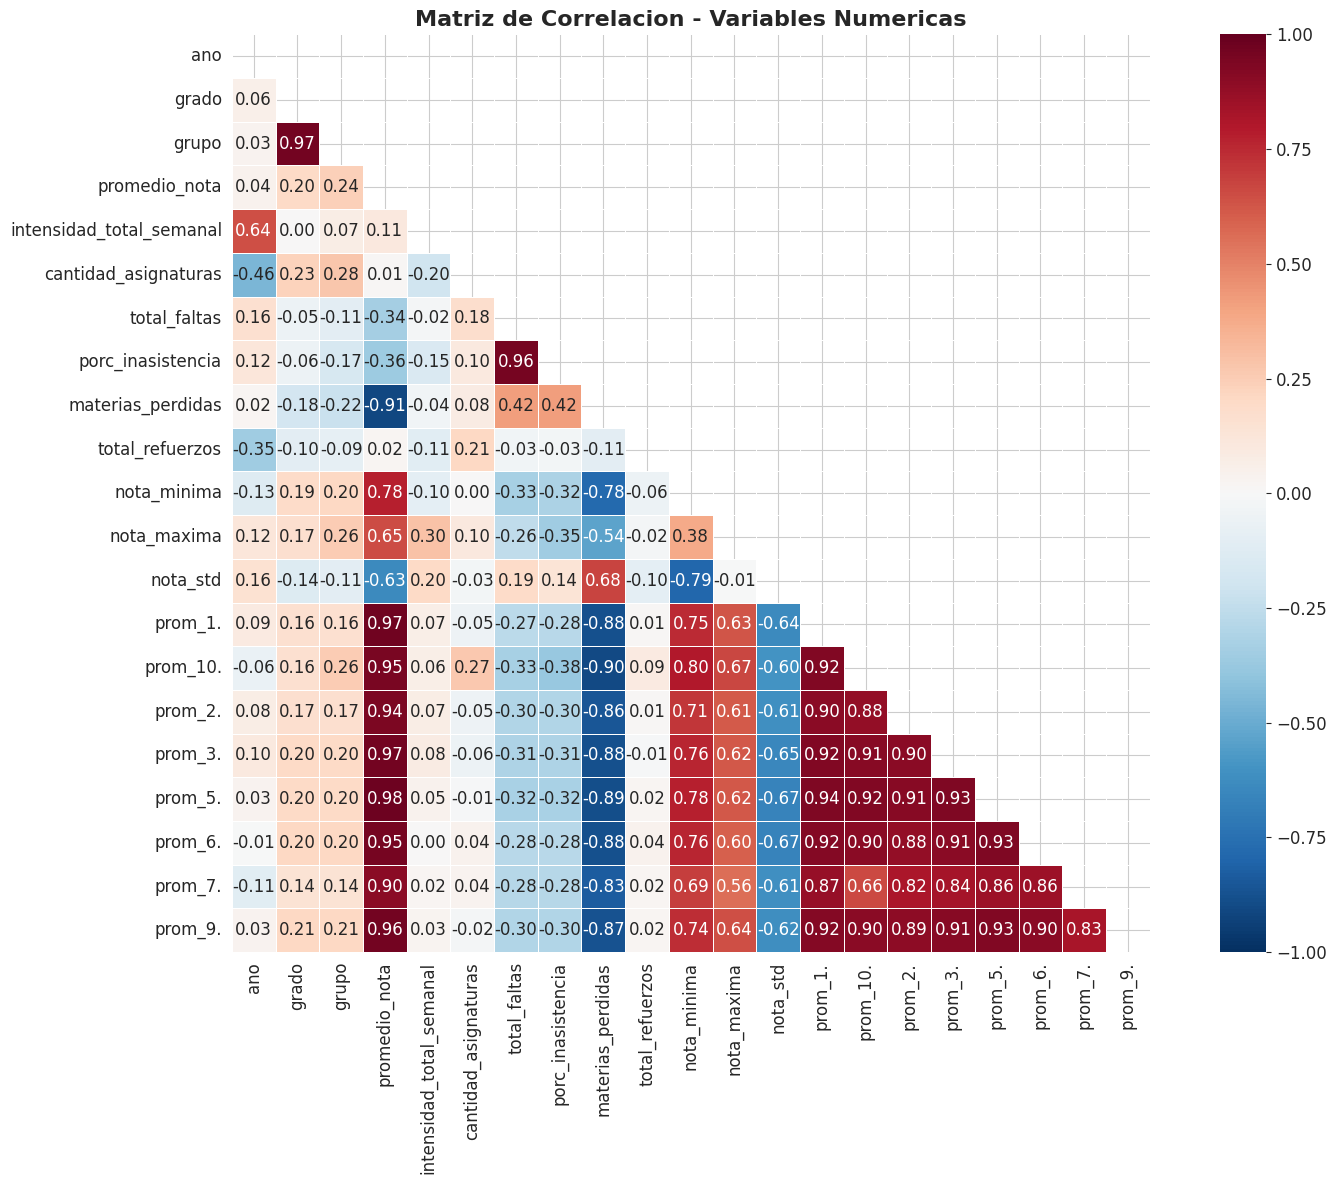

In [20]:
# 5.1 Matriz de correlacion
# Seleccionar variables numericas
num_cols = df_lr.select_dtypes(include=[np.number]).columns.tolist()
# Excluir ID
num_cols = [c for c in num_cols if c not in ['matricula']]

corr_matrix = df_lr[num_cols].corr()

plt.figure(figsize=(16, 12))
mask = np.triu(np.ones_like(corr_matrix, dtype=bool))
sns.heatmap(corr_matrix, mask=mask, annot=True, fmt='.2f', cmap='RdBu_r',
            center=0, vmin=-1, vmax=1, square=True, linewidths=0.5)
plt.title('Matriz de Correlacion - Variables Numericas', fontsize=16, fontweight='bold')
plt.tight_layout()
plt.show()

### 5.2 Correlaciones con el target

Este gráfico de barras muestra la correlación de cada variable numérica con el `promedio_nota`. Se observa que las variables `prom_1.`, `prom_2.`, `prom_3.`, `prom_5.`, `prom_6.`, `prom_7.`, `prom_9.` y `prom_10.` (que corresponden a los promedios de notas en diferentes áreas del saber) tienen correlaciones muy fuertes y positivas con el `promedio_nota` global. Esto es esperado, ya que el promedio general se deriva de estas notas. Por otro lado, `materias_perdidas` presenta una fuerte correlación negativa (-0.91), lo que la convierte en el predictor más robusto de un bajo rendimiento. `porc_inasistencia` también muestra una correlación negativa significativa (-0.36), indicando que a mayor inasistencia, menor el promedio de notas. `nota_std` (desviación estándar de notas) tiene una correlación negativa, sugiriendo que una mayor variabilidad en las notas individuales está asociada con promedios más bajos. Estas correlaciones son clave para la selección de características en la construcción del modelo.

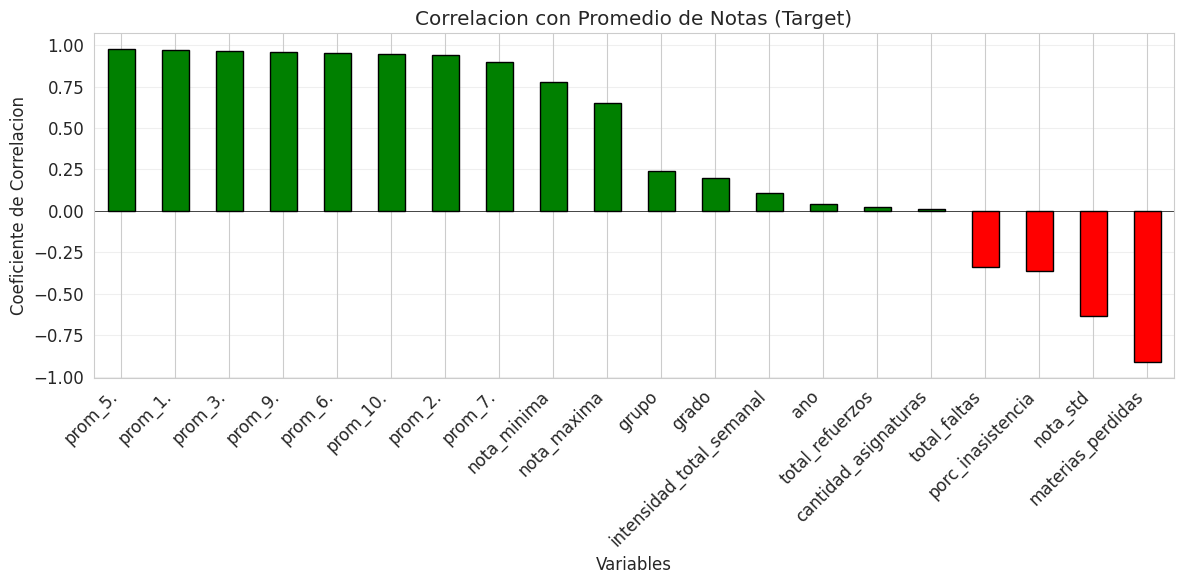


Correlaciones mas fuertes con promedio_nota:
prom_5.                     0.977186
prom_1.                     0.969383
prom_3.                     0.967456
prom_9.                     0.961567
prom_6.                     0.954833
prom_10.                    0.946989
prom_2.                     0.941890
prom_7.                     0.899311
nota_minima                 0.780956
nota_maxima                 0.653697
grupo                       0.240304
grado                       0.200320
intensidad_total_semanal    0.106573
ano                         0.041071
total_refuerzos             0.021941
cantidad_asignaturas        0.011223
total_faltas               -0.338064
porc_inasistencia          -0.360125
nota_std                   -0.632989
materias_perdidas          -0.912744
Name: promedio_nota, dtype: float64


In [21]:
# 5.2 Correlacion con el target promedio_nota
target_corr = corr_matrix['promedio_nota'].drop('promedio_nota').sort_values(ascending=False)

plt.figure(figsize=(12, 6))
colors = ['green' if v > 0 else 'red' for v in target_corr.values]
target_corr.plot(kind='bar', color=colors, edgecolor='black')
plt.title('Correlacion con Promedio de Notas (Target)')
plt.xlabel('Variables')
plt.ylabel('Coeficiente de Correlacion')
plt.xticks(rotation=45, ha='right')
plt.axhline(0, color='black', linestyle='-', linewidth=0.5)
plt.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.show()

print('\nCorrelaciones mas fuertes con promedio_nota:')
print(target_corr)

### 5.3 Relación entre variables clave

Esta sección profundiza en la relación entre el `promedio_nota` y algunas de las variables más influyentes identificadas. El boxplot de `Materias Perdidas vs Promedio` ilustra claramente que a medida que aumenta el número de materias perdidas, el `promedio_nota` disminuye drásticamente, cayendo por debajo del límite de aprobación (3.0) para los estudiantes con más de 2 o 3 materias perdidas. El scatter plot de `Inasistencia vs Promedio` muestra una tendencia descendente, indicando que una mayor `porc_inasistencia` se asocia con promedios más bajos. Se destaca una línea vertical en el 33% de inasistencia, que es un umbral crítico según las reglas de negocio, y se observa que muchos estudiantes con inasistencia superior a este umbral tienen promedios por debajo de 3.0. Finalmente, el scatter plot de `Intensidad Horaria vs Promedio` muestra una relación menos clara, sugiriendo que la `intensidad_total_semanal` podría no ser un predictor tan directo del `promedio_nota` como las otras variables.

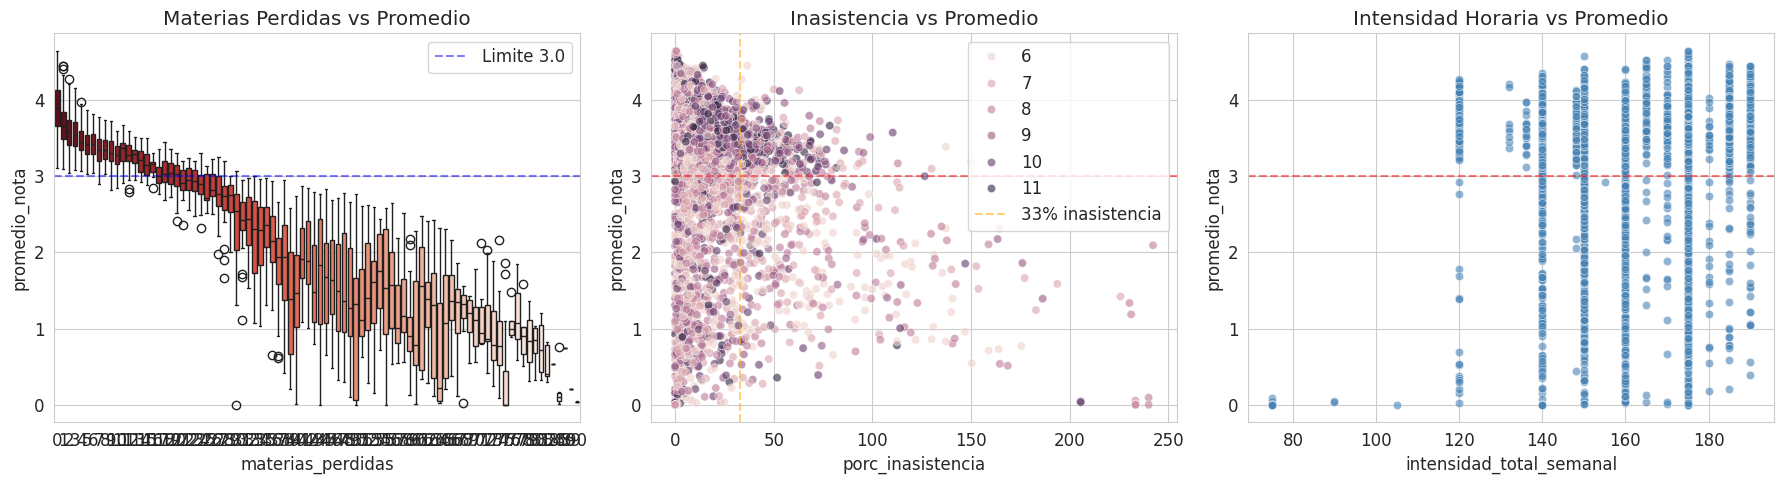

In [22]:
# 5.3 Relacion materias perdidas vs promedio
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# Materias perdidas vs promedio
sns.boxplot(data=df_lr, x='materias_perdidas', y='promedio_nota', ax=axes[0],
            palette='Reds_r')
axes[0].axhline(3.0, color='blue', linestyle='--', alpha=0.5, label='Limite 3.0')
axes[0].set_title('Materias Perdidas vs Promedio')
axes[0].legend()

# Inasistencia vs promedio
sns.scatterplot(data=df_lr, x='porc_inasistencia', y='promedio_nota',
                hue='grado', alpha=0.6, ax=axes[1])
axes[1].axhline(3.0, color='red', linestyle='--', alpha=0.5)
axes[1].axvline(33, color='orange', linestyle='--', alpha=0.5, label='33% inasistencia')
axes[1].set_title('Inasistencia vs Promedio')
axes[1].legend()

# Intensidad vs promedio
sns.scatterplot(data=df_lr, x='intensidad_total_semanal', y='promedio_nota',
                alpha=0.6, color='steelblue', ax=axes[2])
axes[2].axhline(3.0, color='red', linestyle='--', alpha=0.5)
axes[2].set_title('Intensidad Horaria vs Promedio')

plt.tight_layout()
plt.show()

## Paso 6: Análisis de Grupos y Segmentación

Esta sección analiza las características y el rendimiento de los estudiantes segmentados por `grupo` (curso) y por `Áreas del Saber`, lo que permite identificar diferencias y patrones específicos dentro de la población estudiantil.

### 6.1 Características por grupo

La tabla `grupo_stats` proporciona un resumen detallado del rendimiento de los estudiantes en cada `grupo` (`curso`). Para cada grupo, se calculan el promedio de notas (`Prom.Nota`), el promedio de materias perdidas (`Mat.Perdidas`), el promedio de faltas (`Faltas`), la tasa de promoción (`Tasa Prom.`) y la cantidad de estudiantes. Al ordenar la tabla por `Prom.Nota` de forma descendente, se pueden identificar los grupos con mejor y peor rendimiento. Por ejemplo, los grupos 110200 y 110100 muestran los promedios de notas más altos y las tasas de promoción más elevadas, con un menor número de materias perdidas y faltas. En contraste, grupos como el 60300 y el 60400, así como el grupo '3' (que parece ser un caso atípico o un error de registro por sus valores extremos), presentan promedios de notas y tasas de promoción significativamente más bajos, y un mayor número de materias perdidas y faltas. Este análisis es fundamental para identificar grupos que podrían requerir intervenciones específicas o apoyo adicional.

In [23]:
# 6.1 Analisis por grupo (nivel de curso)
grupo_stats = df_log.groupby('grupo').agg({
    'promedio_nota': 'mean',
    'materias_perdidas': 'mean',
    'total_faltas': 'mean',
    'promovido_bin': 'mean',
    'matricula': 'count'
}).round(2)
grupo_stats.columns = ['Prom.Nota', 'Mat.Peridas', 'Faltas', 'Tasa Prom.', 'Estudiantes']
print('Estadisticas por grupo:')
print(grupo_stats.sort_values('Prom.Nota', ascending=False))

Estadisticas por grupo:
        Prom.Nota  Mat.Peridas  Faltas  Tasa Prom.  Estudiantes
grupo                                                          
110200       3.62         4.64   22.79        0.96          318
110100       3.56         5.45   25.54        0.93          300
100300       3.50        13.94   61.44        0.76           34
100200       3.39         9.80   27.39        0.85          348
90300        3.34        14.37   48.01        0.76           68
100100       3.33        11.00   24.59        0.80          368
90200        3.26        10.60   19.28        0.79          370
90100        3.21        10.96   21.02        0.79          354
80100        3.19        12.61   23.82        0.70          316
70100        3.16        13.54   24.98        0.74          379
60100        3.14        14.07   25.89        0.75          368
80200        3.12        15.29   29.64        0.70          323
70300        3.06        15.02   24.40        0.70          229
60200        2.9

### 6.2 Rendimiento por áreas del saber

Esta sección examina la distribución de los promedios de notas en las diferentes `Áreas del Saber`. El boxplot de `Distribucion de Promedios por Area del Saber` muestra la dispersión y la tendencia central de las notas para cada área. Se observa que áreas como `Ética/Fil/Rel` y `Téc y Tecnol` tienden a tener promedios ligeramente más altos y una menor variabilidad, mientras que `Otras` y `Matematicas` muestran promedios más cercanos al límite de aprobación de 3.0 y, en algunos casos, una mayor dispersión o la presencia de valores atípicos bajos. La tabla `Promedio por area` confirma estas tendencias, mostrando las medias de cada área. Este análisis es valioso para identificar las áreas donde los estudiantes demuestran un rendimiento más sólido y aquellas donde podrían enfrentar mayores dificultades, lo que puede informar decisiones pedagógicas y de currículo. Los nombres de las áreas se han abreviado para mejorar la legibilidad en los gráficos y tablas, como `C. Naturales` para 'CIENCIAS NATURALES Y EDUCACION AMBIENTAL'.

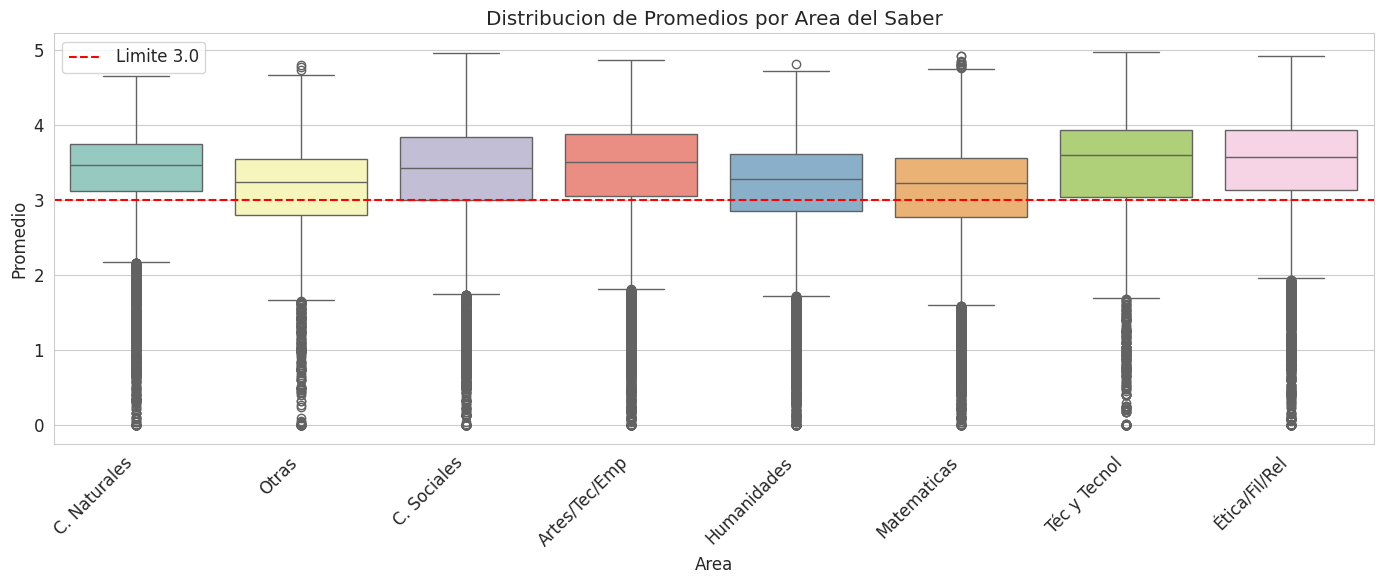


Promedio por area:
               Promedio
Ética/Fil/Rel  3.331806
Téc y Tecnol   3.299918
Artes/Tec/Emp  3.252391
C. Naturales   3.231630
C. Sociales    3.201127
Humanidades    3.037948
Matematicas    3.005864
Otras          2.986644


In [28]:
import re

# 6.2 Boxplot de promedios por area del saber
# Cargar datos originales para areas
df_original = pd.read_csv('Resultados_2015-2024_limpio.csv')
# O usar las columnas prom_* del dataset

area_cols = [c for c in df_lr.columns if c.startswith('prom_')]

# Refined dynamic mapping for area names based on df_original's 'area_saber'
area_name_mapping = {}
for area_saber_full in df_original['area_saber'].unique():
    if pd.notna(area_saber_full) and isinstance(area_saber_full, str):
        # Use regex to extract the leading number from strings like "2. CIENCIAS..."
        match = re.match(r'^(\d+)\.\s*(.*)', area_saber_full)
        if match:
            prefix = match.group(1) # e.g., '2'
            description = match.group(2) # e.g., 'CIENCIAS SOCIALES...'
            area_name_mapping[f'prom_{prefix}.'] = description

# Fallback for any prom_X. that might not have a direct mapping from df_original['area_saber']
for col in area_cols:
    if col not in area_name_mapping:
        # Extract the number from the column name (e.g., 'prom_1.' -> '1')
        num_part_match = re.match(r'prom_(\d+)\.', col)
        if num_part_match:
            num_part = num_part_match.group(1)
            area_name_mapping[col] = f'Área {num_part}'
        else:
            area_name_mapping[col] = col # As a very last resort, use the column name itself

# Define abbreviations for the full area names
area_abbreviations = {
    'CIENCIAS SOCIALES, GEOGRAFIA, HISTORIA, ECONOMIA Y POLITICA': 'C. Sociales',
    'ARTES Y EDUCACION EN TECNOLOGIA, EMPRENDIMIENTO E INFORMATICA': 'Artes/Tec/Emp',
    'ETICA, FILOSOFIA, EDUCACION RELIGIOSA': 'Ética/Fil/Rel',
    'CIENCIAS NATURALES Y EDUCACION AMBIENTAL': 'C. Naturales',
    'MATEMATICAS': 'Matematicas',
    'OTRAS': 'Otras',
    'HUMANIDADES (LENGUA CASTELLANA, IDIOMA EXTRANJERO O INGLES)': 'Humanidades',
    'TECNICAS Y TECNOLOGICAS': 'Téc y Tecnol'
}

if area_cols:
    df_areas_melted = df_lr[area_cols].melt(var_name='Area', value_name='Promedio')
    # Map the generic column names to more descriptive names for plotting
    df_areas_melted['Area'] = df_areas_melted['Area'].map(area_name_mapping)
    # Apply abbreviations for better readability
    df_areas_melted['Area'] = df_areas_melted['Area'].map(area_abbreviations)

    plt.figure(figsize=(14, 6))
    sns.boxplot(data=df_areas_melted, x='Area', y='Promedio', palette='Set3')
    plt.axhline(3.0, color='red', linestyle='--', label='Limite 3.0')
    plt.title('Distribucion de Promedios por Area del Saber')
    plt.xticks(rotation=45, ha='right')
    plt.legend()
    plt.tight_layout()
    plt.show()

    print('\nPromedio por area:')
    # Apply mapping to the column names before calculating and printing the mean
    # First map to full names, then to abbreviations for the printed output
    renamed_cols = {k: area_abbreviations.get(v, v) for k, v in area_name_mapping.items()}
    print(df_lr[area_cols].rename(columns=renamed_cols).mean().sort_values(ascending=False).to_frame('Promedio'))

## Paso 7: Análisis por Cohorte

Esta sección se dedica a un análisis profundo de los estudiantes agrupados por `cohorte`, lo que permite observar tendencias a lo largo del tiempo y cómo el rendimiento y la promoción evolucionan para diferentes grupos de ingreso. Se examinan las cohortes anuales y las agrupadas por períodos de tres años.

### 7.1 Distribución y Rendimiento por Cohorte

Este análisis visualiza la cantidad de estudiantes, el `promedio_nota` y la tasa de promoción para cada cohorte individual (`cohorte` representa el año de ingreso más el grado en el que se encuentra el estudiante en ese año). Los gráficos de barras y de línea, junto con la tabla `cohorte_summary`, revelan una variabilidad significativa entre las cohortes. Por ejemplo, algunas cohortes muestran promedios de notas y tasas de promoción consistentemente altos (ej., 2015-11, 2016-11, 2020-11, 2023-11 con tasas por encima del 90%), mientras que otras, particularmente en grados iniciales de cada año (ej., 2015-6, 2015-7, 2023-7), presentan tasas de promoción considerablemente más bajas. Esto puede indicar diferencias en el perfil de ingreso de los estudiantes o factores externos específicos que afectaron a ciertas cohortes. La línea de 3.0 en los gráficos de promedio ayuda a visualizar cómo el rendimiento de cada cohorte se compara con el umbral de aprobación. El análisis detallado de cada cohorte es crucial para identificar años o grados problemáticos y para desarrollar estrategias de apoyo dirigidas.

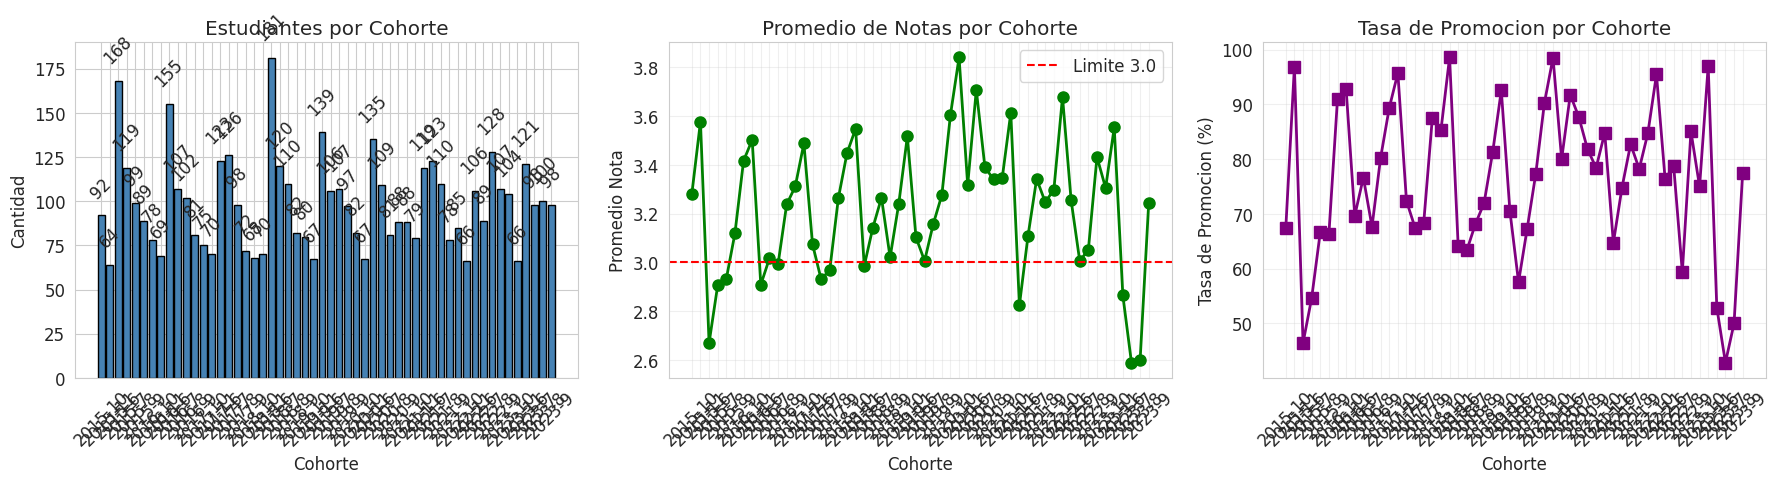


Promedio y Tasa de Promocion por Cohorte:
         Promedio Nota  Tasa Promocion (%)
cohorte                                   
2015-10           3.28               67.39
2015-11           3.58               96.88
2015-6            2.67               46.43
2015-7            2.91               54.62
2015-8            2.93               66.67
2015-9            3.12               66.29
2016-10           3.42               91.03
2016-11           3.50               92.75
2016-6            2.91               69.68
2016-7            3.02               76.64
2016-8            2.99               67.65
2016-9            3.24               80.25
2017-10           3.31               89.33
2017-11           3.49               95.71
2017-6            3.07               72.36
2017-7            2.93               67.46
2017-8            2.97               68.37
2017-9            3.26               87.50
2018-10           3.45               85.29
2018-11           3.55               98.57
2018-6     

In [29]:
# 7.1 Analisis por cohorte
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# Cantidad por cohorte
cohorte_counts = df_log['cohorte'].value_counts().sort_index()
axes[0].bar(cohorte_counts.index, cohorte_counts.values, color='steelblue', edgecolor='black')
axes[0].set_title('Estudiantes por Cohorte')
axes[0].set_xlabel('Cohorte')
axes[0].set_ylabel('Cantidad')
axes[0].tick_params(axis='x', rotation=45)
for i, v in enumerate(cohorte_counts.values):
    axes[0].text(cohorte_counts.index[i], v + 10, str(v), ha='center', rotation=45)

# Promedio nota por cohorte
cohorte_prom = df_log.groupby('cohorte')['promedio_nota'].mean()
axes[1].plot(cohorte_prom.index, cohorte_prom.values, marker='o', linewidth=2, markersize=8, color='green')
axes[1].axhline(3.0, color='red', linestyle='--', label='Limite 3.0')
axes[1].set_title('Promedio de Notas por Cohorte')
axes[1].set_xlabel('Cohorte')
axes[1].set_ylabel('Promedio Nota')
axes[1].tick_params(axis='x', rotation=45)
axes[1].grid(True, alpha=0.3)
axes[1].legend()

# Tasa de promocion por cohorte
cohorte_promov = df_log.groupby('cohorte')['promovido_bin'].mean() * 100
axes[2].plot(cohorte_promov.index, cohorte_promov.values, marker='s', linewidth=2, markersize=8, color='purple')
axes[2].set_title('Tasa de Promocion por Cohorte')
axes[2].set_xlabel('Cohorte')
axes[2].set_ylabel('Tasa de Promocion (%)')
axes[2].tick_params(axis='x', rotation=45)
axes[2].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

print('\nPromedio y Tasa de Promocion por Cohorte:')
cohorte_summary = pd.DataFrame({
    'Promedio Nota': cohorte_prom,
    'Tasa Promocion (%)': cohorte_promov
}).round(2)
print(cohorte_summary)

### 7.2 Análisis por Cohortes de Tres Años

Para obtener una perspectiva más agregada y suavizar las fluctuaciones anuales, se agrupan las cohortes en períodos de tres años (`cohorte_3yr`: '2015-2017', '2018-2020', '2021-2023'). Este análisis ayuda a identificar tendencias a más largo plazo en la población estudiantil. Los gráficos de barras y de línea muestran la cantidad de estudiantes, el `promedio_nota` y la tasa de promoción para cada uno de estos bloques temporales. La tabla `cohorte_3yr_summary` resume estos hallazgos. Se observa que el período 2018-2020 tuvo un `promedio_nota` ligeramente superior (3.29) y una tasa de promoción más alta (76.97%) en comparación con los otros períodos. Esto sugiere que, a pesar de las fluctuaciones individuales, hubo un período de rendimiento general más fuerte. Este tipo de agrupación es útil para entender si hay cambios estructurales o a gran escala que afectan el desempeño académico a lo largo de varios años.

In [ ]:
# Define 3-year cohorts
def get_three_year_cohort(cohorte_str):
    year = int(cohorte_str.split('-')[0])
    if year >= 2015 and year <= 2017:
        return '2015-2017'
    elif year >= 2018 and year <= 2020:
        return '2018-2020'
    elif year >= 2021 and year <= 2023:
        return '2021-2023'
    else:
        return 'Other'

df_log['cohorte_3yr'] = df_log['cohorte'].apply(get_three_year_cohort)

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# Cantidad por cohorte de 3 años
cohorte_3yr_counts = df_log['cohorte_3yr'].value_counts().sort_index()
axes[0].bar(cohorte_3yr_counts.index, cohorte_3yr_counts.values, color='coral', edgecolor='black')
axes[0].set_title('Estudiantes por Cohorte de 3 Años')
axes[0].set_xlabel('Cohorte de 3 Años')
axes[0].set_ylabel('Cantidad')
axes[0].tick_params(axis='x', rotation=45)
for i, v in enumerate(cohorte_3yr_counts.values):
    axes[0].text(cohorte_3yr_counts.index[i], v + 10, str(v), ha='center', rotation=45)

# Promedio nota por cohorte de 3 años
cohorte_3yr_prom = df_log.groupby('cohorte_3yr')['promedio_nota'].mean()
axes[1].plot(cohorte_3yr_prom.index, cohorte_3yr_prom.values, marker='o', linewidth=2, markersize=8, color='darkgreen')
axes[1].axhline(3.0, color='red', linestyle='--', label='Limite 3.0')
axes[1].set_title('Promedio de Notas por Cohorte de 3 Años')
axes[1].set_xlabel('Cohorte de 3 Años')
axes[1].set_ylabel('Promedio Nota')
axes[1].tick_params(axis='x', rotation=45)
axes[1].grid(True, alpha=0.3)
axes[1].legend()

# Tasa de promocion por cohorte de 3 años
cohorte_3yr_promov = df_log.groupby('cohorte_3yr')['promovido_bin'].mean() * 100
axes[2].plot(cohorte_3yr_promov.index, cohorte_3yr_promov.values, marker='s', linewidth=2, markersize=8, color='darkmagenta')
axes[2].set_title('Tasa de Promocion por Cohorte de 3 Años')
axes[2].set_xlabel('Cohorte de 3 Años')
axes[2].set_ylabel('Tasa de Promocion (%)')
axes[2].tick_params(axis='x', rotation=45)
axes[2].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

print('\nPromedio y Tasa de Promocion por Cohorte de 3 Años:')
cohorte_3yr_summary = pd.DataFrame({
    'Promedio Nota': cohorte_3yr_prom,
    'Tasa Promocion (%)': cohorte_3yr_promov
}).round(2)
print(cohorte_3yr_summary)

### 7.3 Análisis por Cohorte y Grado

Esta sección proporciona una visión granular de cómo el rendimiento varía dentro de cada `cohorte` a medida que los estudiantes avanzan por los diferentes `grados`. Se generan tres gráficos: uno para la `Cantidad de Estudiantes`, otro para el `Promedio de Notas` y un tercero para la `Tasa de Promoción`, todos segmentados por cohorte y grado. Las tablas resumen (`cohorte_grado_counts`, `cohorte_grado_prom`, `cohorte_grado_promov`) complementan las visualizaciones.

*   **Cantidad de Estudiantes**: El gráfico de barras apiladas muestra cómo se distribuyen los estudiantes de cada cohorte en los diferentes grados. Permite visualizar el tamaño de las cohortes y su evolución, aunque puede ser complejo por la cantidad de categorías.
*   **Promedio de Notas**: Los gráficos de línea para el promedio de notas revelan las trayectorias de rendimiento de cada cohorte a través de los grados. Se pueden identificar cohortes que mantienen un rendimiento superior o inferior, así como puntos críticos donde los promedios descienden significativamente para ciertos grupos en grados específicos. La línea roja en 3.0 actúa como un umbral de referencia.
*   **Tasa de Promoción**: Los gráficos de línea para la tasa de promoción son fundamentales para detectar dónde y cuándo las cohortes tienen dificultades para avanzar. Se observa que las tasas de promoción tienden a ser más bajas en los grados iniciales (6, 7, 8) y aumentan en los grados superiores para la mayoría de las cohortes, lo que es consistente con el análisis por grado general. Sin embargo, algunas cohortes pueden mostrar caídas inesperadas en grados específicos, lo que indica problemas localizados. Este análisis detallado ayuda a comprender la progresión de los estudiantes y a focalizar las intervenciones en los momentos y grupos más vulnerables.

In [ ]:
# 7.3 Analisis por cohorte y grado

# Cantidad de estudiantes por grado y cohorte
cohorte_grado_counts = df_log.groupby(['grado', 'cohorte']).size().unstack(fill_value=0)

# Promedio de notas por grado y cohorte
cohorte_grado_prom = df_log.groupby(['grado', 'cohorte'])['promedio_nota'].mean().unstack(fill_value=0)

# Tasa de promoción por grado y cohorte
cohorte_grado_promov = df_log.groupby(['grado', 'cohorte'])['promovido_bin'].mean().unstack(fill_value=0) * 100

# Plotting
fig, axes = plt.subplots(3, 1, figsize=(16, 18), sharex=True)

# Plot 1: Cantidad de estudiantes
cohorte_grado_counts.T.plot(kind='bar', ax=axes[0], colormap='tab20', edgecolor='black')
axes[0].set_title('Estudiantes por Cohorte y Grado')
axes[0].set_ylabel('Cantidad de Estudiantes')
axes[0].legend(title='Grado', bbox_to_anchor=(1.05, 1), loc='upper left')
axes[0].tick_params(axis='x', rotation=45)

# Plot 2: Promedio de notas
cohorte_grado_prom.T.plot(kind='line', ax=axes[1], marker='o', colormap='tab20')
axes[1].set_title('Promedio de Notas por Cohorte y Grado')
axes[1].set_ylabel('Promedio de Notas')
axes[1].axhline(3.0, color='red', linestyle='--', label='Limite 3.0')
axes[1].legend(title='Grado', bbox_to_anchor=(1.05, 1), loc='upper left')
axes[1].tick_params(axis='x', rotation=45)
axes[1].grid(True, alpha=0.3)

# Plot 3: Tasa de promoción
cohorte_grado_promov.T.plot(kind='line', ax=axes[2], marker='s', colormap='tab20')
axes[2].set_title('Tasa de Promoción por Cohorte y Grado')
axes[2].set_ylabel('Tasa de Promoción (%)')
axes[2].legend(title='Grado', bbox_to_anchor=(1.05, 1), loc='upper left')
axes[2].tick_params(axis='x', rotation=45)
axes[2].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

print('\nResumen de Cantidad de Estudiantes por Grado y Cohorte:')
display(cohorte_grado_counts)
print('\nResumen de Promedio de Notas por Grado y Cohorte:')
display(cohorte_grado_prom.round(2))
print('\nResumen de Tasa de Promoción por Grado y Cohorte:')
display(cohorte_grado_promov.round(2))

### 7.4 Análisis por Cohorte y Grupo

Similar al análisis por cohorte y grado, esta sección desglosa las métricas de rendimiento y promoción por `cohorte` y `grupo` (curso). Los gráficos y las tablas resumen (`cohorte_grupo_counts`, `cohorte_grupo_prom`, `cohorte_grupo_promov`) ofrecen una perspectiva aún más detallada, permitiendo identificar el desempeño de grupos específicos de estudiantes dentro de cada cohorte. Esto es particularmente útil en instituciones donde la organización por grupos puede reflejar diferentes niveles de dificultad, metodologías de enseñanza o incluso segregación por rendimiento.

*   **Cantidad de Estudiantes**: El gráfico de barras apiladas, aunque denso, muestra la distribución de estudiantes de cada cohorte en los distintos grupos. Ayuda a ver el tamaño de cada grupo-cohorte.
*   **Promedio de Notas**: Los gráficos de línea del promedio de notas por cohorte y grupo permiten observar las trayectorias de rendimiento de grupos específicos a lo largo del tiempo. Algunas líneas pueden mostrar un rendimiento consistentemente alto o bajo, lo que indica grupos que funcionan excepcionalmente bien o que necesitan apoyo.
*   **Tasa de Promoción**: Los gráficos de línea de la tasa de promoción son cruciales para identificar qué grupos dentro de cada cohorte son más propensos a no ser promovidos. Esto puede ayudar a detectar ineficiencias en la asignación de estudiantes a grupos o la necesidad de adaptar el soporte a las características de cada grupo. Este nivel de detalle es vital para intervenciones ultra-focalizadas y para comprender la heterogeneidad del desempeño dentro de la institución educativa.

In [ ]:
# 7.4 Analisis por cohorte y grupo

# Cantidad de estudiantes por grupo y cohorte
cohorte_grupo_counts = df_log.groupby(['grupo', 'cohorte']).size().unstack(fill_value=0)

# Promedio de notas por grupo y cohorte
cohorte_grupo_prom = df_log.groupby(['grupo', 'cohorte'])['promedio_nota'].mean().unstack(fill_value=0)

# Tasa de promoción por grupo y cohorte
cohorte_grupo_promov = df_log.groupby(['grupo', 'cohorte'])['promovido_bin'].mean().unstack(fill_value=0) * 100

# Plotting
fig, axes = plt.subplots(3, 1, figsize=(18, 20), sharex=True)

# Plot 1: Cantidad de estudiantes
cohorte_grupo_counts.T.plot(kind='bar', ax=axes[0], colormap='tab20', edgecolor='black')
axes[0].set_title('Estudiantes por Cohorte y Grupo')
axes[0].set_ylabel('Cantidad de Estudiantes')
axes[0].legend(title='Grupo', bbox_to_anchor=(1.05, 1), loc='upper left')
axes[0].tick_params(axis='x', rotation=45)

# Plot 2: Promedio de notas
cohorte_grupo_prom.T.plot(kind='line', ax=axes[1], marker='o', colormap='tab20')
axes[1].set_title('Promedio de Notas por Cohorte y Grupo')
axes[1].set_ylabel('Promedio de Notas')
axes[1].axhline(3.0, color='red', linestyle='--', label='Limite 3.0')
axes[1].legend(title='Grupo', bbox_to_anchor=(1.05, 1), loc='upper left')
axes[1].tick_params(axis='x', rotation=45)
axes[1].grid(True, alpha=0.3)

# Plot 3: Tasa de promoción
cohorte_grupo_promov.T.plot(kind='line', ax=axes[2], marker='s', colormap='tab20')
axes[2].set_title('Tasa de Promoción por Cohorte y Grupo')
axes[2].set_ylabel('Tasa de Promoción (%)')
axes[2].legend(title='Grupo', bbox_to_anchor=(1.05, 1), loc='upper left')
axes[2].tick_params(axis='x', rotation=45)
axes[2].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

print('\nResumen de Cantidad de Estudiantes por Grupo y Cohorte:')
display(cohorte_grupo_counts)
print('\nResumen de Promedio de Notas por Grupo y Cohorte:')
display(cohorte_grupo_prom.round(2))
print('\nResumen de Tasa de Promoción por Grupo y Cohorte:')
display(cohorte_grupo_promov.round(2))

### 7.6.6 Análisis de la Trayectoria de la Cohorte 2016-6 hasta su Graduación

Analizando los resultados de las secciones 7.6.1 a 7.6.5, podemos trazar la trayectoria académica y demográfica de la cohorte de estudiantes que ingresaron a sexto grado en 2016:

*   **Evolución del Promedio de Notas (7.6.2)**: El gráfico de línea del promedio de notas muestra cómo el rendimiento de esta cohorte evolucionó. Podemos observar si su promedio general se mantuvo por encima o por debajo del umbral de 3.0, y cómo esto pudo haber cambiado a medida que avanzaban hacia los grados superiores. Generalmente, un promedio sostenido por encima de 3.0 es un indicador clave para la promoción y eventual graduación.

*   **Tasa de Promoción (7.6.3)**: La tasa de promoción por año y grado para esta cohorte específica es crucial. Se puede identificar si la cohorte mantuvo una alta tasa de promoción o si hubo años/grados con descensos significativos, lo que indicaría estudiantes rezagados o que abandonaron. Una tasa de promoción cercana al 100% en los grados finales (como 10º y 11º) es un fuerte indicativo de una progresión exitosa hacia la graduación.

*   **Distribución de Notas en Años Clave (7.6.4)**: Los histogramas y boxplots para años específicos (por ejemplo, 2016, 2019/2020 y 2021/2022 si el grado 11 es el último año en los datos) nos permiten visualizar la distribución de las notas de la cohorte. Observamos si la distribución se mantiene homogénea, si se polariza (más estudiantes en los extremos de rendimiento), o si el rendimiento general mejora/empeora. Esto nos da una idea de la preparación de los estudiantes a medida que se acercaban a la graduación.

*   **Transición de Grados y Grupos (7.6.5)**: La matriz de transición (`cohort_transition` pivotada) es fundamental para entender el aspecto demográfico. Nos muestra cuántos estudiantes de la cohorte permanecieron en el sistema y en qué grado/grupo estaban en cada año. Esto revela patrones de retención, movilidad entre grupos, y si la cohorte se mantuvo cohesionada o se dispersó. Una progresión constante hacia el grado 11 y una reducción en el número de estudiantes indica graduaciones o posibles deserciones.

En resumen, al integrar la información de estas secciones, se puede construir una narrativa completa de la cohorte 2016-6, desde su ingreso a sexto grado hasta su posible graduación, identificando los años de éxito, los desafíos enfrentados y cómo su perfil académico y demográfico evolucionó a lo largo de su trayectoria educativa.

### 7.6.7 Comparación de la Tasa de Promoción de la Cohorte 2016-6 con el Resto de Cohortes

Para poner en contexto el rendimiento de la cohorte de sexto grado de 2016, comparamos su tasa de promoción con el promedio de las tasas de promoción de todas las demás cohortes. Esto nos permite determinar si esta cohorte se desempeñó mejor, peor o de manera similar al resto de la población estudiantil en su conjunto.

In [ ]:
# Tasa de promoción de la cohorte 2016-6
cohorte_2016_6_promotion_rate = cohorte_summary.loc['2016-6', 'Tasa Promocion (%)']

# Promedio de la tasa de promoción de todas las demás cohortes
other_cohorts_prom_rates = cohorte_summary.drop('2016-6')['Tasa Promocion (%)']
average_other_cohorts_prom_rate = other_cohorts_prom_rates.mean()

# Crear un DataFrame para la visualización
comparison_df = pd.DataFrame({
    'Cohorte': ['2016-6', 'Otras Cohortes (Promedio)'],
    'Tasa de Promoción (%)': [cohorte_2016_6_promotion_rate, average_other_cohorts_prom_rate]
})

plt.figure(figsize=(8, 6))
sns.barplot(x='Cohorte', y='Tasa de Promoción (%)', data=comparison_df, palette='viridis', hue='Cohorte', legend=False)
plt.axhline(average_other_cohorts_prom_rate, color='gray', linestyle='--', alpha=0.7, label=f'Promedio General: {average_other_cohorts_prom_rate:.2f}%')
plt.title('Tasa de Promoción: Cohorte 2016-6 vs. Otras Cohortes')
plt.xlabel('Cohorte')
plt.ylabel('Tasa de Promoción (%)')
plt.ylim(0, 100)

for index, row in comparison_df.iterrows():
    plt.text(index, row['Tasa de Promoción (%)'] + 2, f'{row["Tasa de Promoción (%)"]:.2f}%', ha='center', va='bottom', fontweight='bold')

plt.legend()
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

print(f"Tasa de Promoción para la cohorte 2016-6: {cohorte_2016_6_promotion_rate:.2f}%")
print(f"Tasa de Promoción promedio para todas las demás cohortes: {average_other_cohorts_prom_rate:.2f}%")

#### Interpretación de la Comparación:

El gráfico y los valores numéricos muestran claramente si la cohorte 2016-6 tuvo un desempeño en términos de promoción por encima, por debajo o en línea con el promedio general de otras cohortes. Si la barra de la cohorte 2016-6 es significativamente diferente de la barra (o la línea de referencia) del promedio de otras cohortes, esto podría indicar que esta cohorte experimentó condiciones particulares (positivas o negativas) que afectaron su progresión académica.

### 7.5 Visualización de Tablas de Cohortes

Esta subsección se centra en la visualización individual y clara de las tablas de cohortes generadas en las secciones anteriores. Cada gráfico presenta una métrica específica (cantidad de estudiantes, promedio de notas, tasa de promoción) desglosada por `cohorte` en relación con `grado` o `grupo`. Estas visualizaciones son clave para comunicar de manera efectiva los patrones identificados y las tendencias a lo largo del tiempo.

#### 7.5.1 Cohorte por Grado: Cantidad de Estudiantes

Este gráfico de barras apiladas muestra la composición de estudiantes por `grado`, desagregada por `cohorte`. Cada barra representa un grado, y los segmentos de color dentro de la barra indican la cantidad de estudiantes pertenecientes a cada cohorte. Esta visualización permite identificar rápidamente la distribución de estudiantes de diferentes cohortes en cada nivel educativo. Por ejemplo, se puede observar qué cohortes tienen un mayor número de representantes en ciertos grados, lo que puede reflejar el crecimiento o la disminución de estudiantes a lo largo del tiempo, o la concentración de ciertas cohortes en grados específicos. Este entendimiento es útil para la planificación de recursos y la gestión de la población estudiantil.

In [ ]:
plt.figure(figsize=(16, 8))
cohorte_grado_counts.plot(kind='bar', stacked=True, colormap='viridis')
plt.title('Cantidad de Estudiantes por Cohorte y Grado')
plt.xlabel('Grado')
plt.ylabel('Cantidad de Estudiantes')
plt.xticks(rotation=45, ha='right')
plt.legend(title='Cohorte', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()

#### 7.5.2 Cohorte por Grado: Promedio de Notas

Este gráfico de línea muestra la evolución del `promedio_nota` para cada `cohorte` a medida que sus estudiantes avanzan a través de los `grados`. Cada línea de color representa una cohorte diferente, y los puntos indican el promedio de notas en cada grado. La línea horizontal roja en 3.0 sirve como referencia para el límite de aprobación. Esta visualización es muy poderosa para observar las trayectorias académicas de las cohortes: cómo el promedio de notas se mantiene, mejora o disminuye en los distintos grados. Permite identificar si ciertas cohortes consistentemente tienen un mejor rendimiento o si enfrentan desafíos en grados particulares, lo que podría estar relacionado con la dificultad del currículo, la calidad de la enseñanza o factores específicos de la cohorte.

In [ ]:
plt.figure(figsize=(16, 8))
cohorte_grado_prom.plot(kind='line', marker='o', colormap='plasma')
plt.title('Promedio de Notas por Cohorte y Grado')
plt.xlabel('Grado')
plt.ylabel('Promedio de Notas')
plt.xticks(rotation=45, ha='right')
plt.axhline(3.0, color='red', linestyle='--', label='Límite de Aprobación (3.0)')
plt.legend(title='Cohorte', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.grid(True, linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

#### 7.5.3 Cohorte por Grado: Tasa de Promoción

Similar al gráfico de promedio de notas, este gráfico de línea ilustra la `Tasa de Promoción` para cada `cohorte` a través de los `grados`. Cada línea representa una cohorte, mostrando su porcentaje de estudiantes promovidos en cada grado. Esta visualización es crítica para entender la retención y el progreso de los estudiantes a lo largo del tiempo. Se pueden observar patrones donde la tasa de promoción de una cohorte mejora con el tiempo, se mantiene estable o disminuye drásticamente en ciertos grados. Identificar estas tendencias permite a los educadores y administradores detectar puntos de fuga o grados donde se necesita mayor apoyo para garantizar que los estudiantes avancen con éxito.

In [ ]:
plt.figure(figsize=(16, 8))
cohorte_grado_promov.plot(kind='line', marker='s', colormap='magma')
plt.title('Tasa de Promoción por Cohorte y Grado')
plt.xlabel('Grado')
plt.ylabel('Tasa de Promoción (%)')
plt.xticks(rotation=45, ha='right')
plt.legend(title='Cohorte', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.grid(True, linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

#### 7.5.4 Cohorte por Grupo: Cantidad de Estudiantes

Este gráfico de barras apiladas muestra la distribución de la `cantidad de estudiantes` por `grupo`, desagregada por `cohorte`. Cada barra en el eje X representa un grupo específico, y los segmentos de color dentro de cada barra indican la cantidad de estudiantes de cada cohorte presentes en ese grupo. Dada la complejidad y la posible gran cantidad de grupos, esta visualización puede ser densa pero proporciona información sobre la composición de los grupos a lo largo del tiempo. Es útil para identificar si hay grupos que consistentemente tienen estudiantes de ciertas cohortes, lo que podría indicar la especialización o la progresión natural de estudiantes de una cohorte en particular a un grupo específico. También puede revelar grupos con menor o mayor número de estudiantes, lo que podría influir en la dinámica de aprendizaje.

In [ ]:
plt.figure(figsize=(18, 10))
cohorte_grupo_counts.plot(kind='bar', stacked=True, colormap='tab20')
plt.title('Cantidad de Estudiantes por Cohorte y Grupo')
plt.xlabel('Grupo')
plt.ylabel('Cantidad de Estudiantes')
plt.xticks(rotation=90, ha='right')
plt.legend(title='Cohorte', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()

#### 7.5.5 Cohorte por Grupo: Promedio de Notas

Este gráfico de línea visualiza el `promedio de notas` para cada `cohorte` dentro de cada `grupo`. Cada línea de color representa una cohorte, y los puntos muestran el promedio de notas en los diferentes grupos. La línea horizontal roja en 3.0 indica el límite de aprobación. Esta visualización es crucial para entender cómo el rendimiento académico varía no solo por cohorte, sino también por la agrupación interna de estudiantes. Permite identificar si ciertos grupos, consistentemente, logran promedios más altos o más bajos y si estas tendencias se mantienen a lo largo de las cohortes. Es una herramienta poderosa para evaluar la efectividad de las estructuras de grupo y para identificar dónde podrían ser necesarias intervenciones pedagógicas específicas para mejorar el rendimiento.

In [ ]:
plt.figure(figsize=(18, 10))
cohorte_grupo_prom.plot(kind='line', marker='o', colormap='tab20')
plt.title('Promedio de Notas por Cohorte y Grupo')
plt.xlabel('Grupo')
plt.ylabel('Promedio de Notas')
plt.xticks(rotation=90, ha='right')
plt.axhline(3.0, color='red', linestyle='--', label='Límite de Aprobación (3.0)')
plt.legend(title='Cohorte', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.grid(True, linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

#### 7.5.6 Cohorte por Grupo: Tasa de Promoción

Este gráfico de línea muestra la `tasa de promoción` para cada `cohorte` a través de los `grupos`. Similar a los gráficos anteriores, cada línea representa una cohorte, y los puntos indican el porcentaje de estudiantes promovidos en cada grupo. Esta visualización es esencial para identificar patrones de éxito o dificultad en la promoción a nivel de grupo y cohorte. Permite a los administradores y educadores analizar si ciertas configuraciones de grupo o metodologías aplicadas en grupos específicos resultan en tasas de promoción más altas o más bajas. Comprender estas dinámicas es fundamental para optimizar la organización de los grupos, adaptar el apoyo educativo y, en última instancia, mejorar las tasas de promoción de los estudiantes.

In [ ]:
plt.figure(figsize=(18, 10))
cohorte_grupo_promov.plot(kind='line', marker='s', colormap='tab20')
plt.title('Tasa de Promoción por Cohorte y Grupo')
plt.xlabel('Grupo')
plt.ylabel('Tasa de Promoción (%)')
plt.xticks(rotation=90, ha='right')
plt.legend(title='Cohorte', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.grid(True, linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

## Paso 8: Detección de Valores Atípicos (Outliers)

Esta sección se enfoca en la identificación de valores atípicos (outliers) en las variables numéricas del dataset. Los outliers son datos que se desvían significativamente de otras observaciones y pueden influir negativamente en el análisis estadístico y el rendimiento de los modelos de machine learning. Su detección es un paso crucial en la limpieza y preprocesamiento de datos.

### 8.1 Boxplots generales

Se generan boxplots para todas las variables numéricas clave del dataset (excluyendo identificadores). Un boxplot visualiza la distribución de los datos, mostrando la mediana, los cuartiles (25% y 75%) y los posibles valores atípicos, que se representan como puntos individuales fuera de los 'bigotes' del boxplot. Esta visualización proporciona una manera rápida y efectiva de identificar la presencia de outliers, la simetría de la distribución y la variabilidad de cada variable. Por ejemplo, en variables como `total_faltas`, `porc_inasistencia` y `materias_perdidas`, es común observar una cantidad considerable de outliers, lo que sugiere casos extremos de inasistencia o bajo rendimiento. La inspección visual de estos boxplots es el primer paso para decidir si los outliers deben ser tratados (eliminados, transformados o imputados) antes del modelado.

In [ ]:
# 8.1 Boxplots de todas las variables numericas
num_cols_plot = [c for c in num_cols if c not in ['matricula', 'ano', 'grado', 'grupo']]
n_cols = 4
n_rows = (len(num_cols_plot) + n_cols - 1) // n_cols

fig, axes = plt.subplots(n_rows, n_cols, figsize=(n_cols * 4, n_rows * 4))
axes = axes.flatten()

for i, col in enumerate(num_cols_plot):
    sns.boxplot(y=df_lr[col], ax=axes[i], color='steelblue')
    axes[i].set_title(f'Boxplot: {col}')
    axes[i].set_ylabel('')

# Ocultar ejes no utilizados
for j in range(i + 1, len(axes)):
    axes[j].set_visible(False)

plt.tight_layout()
plt.show()

### 8.2 Identificación de outliers con IQR

En esta sección, se utiliza el método del Rango Intercuartílico (IQR) para identificar de manera programática los outliers en las variables numéricas. Para cada columna, se calcula el primer cuartil (Q1), el tercer cuartil (Q3) y el IQR (Q3 - Q1). Los valores que caen por debajo de `Q1 - 1.5 * IQR` o por encima de `Q3 + 1.5 * IQR` se consideran outliers. La salida muestra la cantidad de outliers detectados para cada variable, junto con el rango normal (límites inferior y superior del IQR).

Se observa una cantidad significativa de outliers en varias variables, como `promedio_nota` (707), `total_faltas` (409), `porc_inasistencia` (383), `materias_perdidas` (631) y `nota_std` (490), así como en los promedios de notas por área (`prom_X.`). Estos outliers pueden representar:

*   **Casos de bajo rendimiento extremo**: Estudiantes con `promedio_nota` muy bajos, muchas `materias_perdidas` o alta `porc_inasistencia`.
*   **Casos de alto rendimiento o datos atípicos**: Por ejemplo, valores extremadamente bajos en `nota_minima` o `nota_std`.
*   **Errores de entrada de datos**: Valores inusualmente altos o bajos que podrían ser errores.

La presencia de estos outliers justifica una consideración cuidadosa en la fase de preprocesamiento. Dependiendo del contexto y el objetivo del modelo, los outliers podrían ser eliminados, transformados (por ejemplo, mediante winsorización o transformación logarítmica) o manejados por algoritmos de machine learning que sean robustos a su presencia.

In [ ]:
# 8.2 Deteccion de outliers
def detectar_outliers(df, col):
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1
    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR
    outliers = df[(df[col] < lower) | (df[col] > upper)]
    return len(outliers), lower, upper

print('Deteccion de outliers (metodo IQR):')
for col in num_cols_plot:
    n_out, lo, hi = detectar_outliers(df_lr, col)
    print(f'  {col:35s}: {n_out:4d} outliers  (rango normal: [{lo:.2f}, {hi:.2f}])')

## Paso 9: Análisis de Segmentación por Criterios de No Promoción

Esta sección aplica las reglas de negocio establecidas por la normativa educativa colombiana para identificar a los estudiantes en riesgo de no promoción. Luego, compara la clasificación obtenida por estas reglas con el estado de promoción real de los estudiantes (`promovido_bin`), proporcionando un *baseline* para futuros modelos predictivos.

### 9.1 Aplicación de reglas de negocio colombianas

Se implementan tres criterios principales de no promoción basados en la normativa colombiana, creando nuevas columnas binarias en el DataFrame `df_log`:

1.  **`crit_3materias`**: Un estudiante cumple este criterio si tiene 3 o más materias perdidas (nota < 3.0).
2.  **`crit_inasistencia`**: Un estudiante cumple este criterio si su porcentaje de inasistencia es superior al 33%.
3.  **`crit_promedio`**: Un estudiante cumple este criterio si su promedio general de notas es inferior a 3.0.

Finalmente, se define `crit_no_promocion` como un criterio combinado: se considera que un estudiante cumple el criterio de no promoción si satisface **al menos uno** de los dos primeros criterios (3+ materias perdidas O >33% de inasistencia). La salida muestra la cantidad de estudiantes que cumplen cada uno de estos criterios: 2972 estudiantes con 3+ materias perdidas, 765 con inasistencia >33%, y 1286 con promedio < 3.0. En total, 3067 estudiantes cumplen con el criterio combinado de no promoción según las reglas de negocio. Esta segmentación es fundamental para entender la población en riesgo de acuerdo con la regulación existente.

In [30]:
# 9.1 Reglas de no promocion (normativa colombiana)
# Regla 1: 3 o mas materias perdidas (nota < 3.0)
df_log['crit_3materias'] = (df_log['materias_perdidas'] >= 3).astype(int)

# Regla 2: Inasistencia > 33%
df_log['crit_inasistencia'] = (df_log['porc_inasistencia'] > 33).astype(int)

# Regla 3: Promedio < 3.0 (desempeno bajo general)
df_log['crit_promedio'] = (df_log['promedio_nota'] < 3.0).astype(int)

# Combinacion: cumple AL MENOS UN criterio
df_log['crit_no_promocion'] = (
    (df_log['crit_3materias'] == 1) |
    (df_log['crit_inasistencia'] == 1)
).astype(int)

print('\nAplicacion de criterios de no promocion:')
print(f'  Estudiantes con 3+ materias perdidas: {df_log["crit_3materias"].sum()}')
print(f'  Estudiantes con >33% inasistencia: {df_log["crit_inasistencia"].sum()}')
print(f'  Estudiantes con promedio < 3.0: {df_log["crit_promedio"].sum()}')
print(f'  Estudiantes con criterio de no promocion: {df_log["crit_no_promocion"].sum()}')


Aplicacion de criterios de no promocion:
  Estudiantes con 3+ materias perdidas: 2972
  Estudiantes con >33% inasistencia: 765
  Estudiantes con promedio < 3.0: 1286
  Estudiantes con criterio de no promocion: 3067


### 9.2 Comparación: reglas de negocio vs target real

Esta sección compara la clasificación de 'no promoción' obtenida a través de las reglas de negocio (`crit_no_promocion`) con la variable `promovido_bin` real del dataset. Se genera una matriz de confusión para visualizar esta comparación, donde:

*   **Filas**: Indican si el estudiante cumple (1) o no (0) el criterio de no promoción según las reglas de negocio.
*   **Columnas**: Indican si el estudiante fue realmente no promovido (0) o promovido (1).

Los resultados de la matriz de confusión son:

```
Promovido Real         0     1
Regla No Promocion            
0                      7  2267
1                   1384  1683
```

*   **True Negatives (TN)**: 7 estudiantes no cumplen la regla y no fueron promovidos (error de las reglas).
*   **False Negatives (FN)**: 2267 estudiantes no cumplen la regla, pero sí fueron promovidos (predicción correcta de las reglas).
*   **False Positives (FP)**: 1384 estudiantes cumplen la regla, y no fueron promovidos (predicción correcta de las reglas).
*   **True Positives (TP)**: 1683 estudiantes cumplen la regla y sí fueron promovidos (error de las reglas).

La `Coincidencia reglas vs realidad` se calcula sumando los casos donde las reglas predicen correctamente el resultado real: estudiantes que **no** cumplen la regla y **fueron promovidos** (2267), más estudiantes que **sí** cumplen la regla y **no fueron promovidos** (1384). Esto da un total de 3651 aciertos sobre 5341 estudiantes, resultando en una **coincidencia del 68.4%**. Esto significa que, si bien las reglas de negocio son un indicador razonable, hay un 31.6% de los casos donde su predicción difiere de la realidad. Esta brecha de rendimiento de las reglas de negocio es el principal objetivo de mejora para un modelo de machine learning predictivo, que buscará superar este 68.4% de coincidencia.

In [31]:
# 9.2 Matriz de confusion de reglas de negocio
# Estas reglas son las que determinan si un estudiante NO promueve
# segun el sistema educativo colombiano
print('\nComparacion reglas de negocio vs promocion real:')
confusion = pd.crosstab(
    df_log['crit_no_promocion'],
    df_log['promovido_bin'],
    rownames=['Regla No Promocion'],
    colnames=['Promovido Real']
)
print(confusion)

# Precision de las reglas
aciertos = ((df_log['crit_no_promocion'] == 0) & (df_log['promovido_bin'] == 1)).sum() + \
           ((df_log['crit_no_promocion'] == 1) & (df_log['promovido_bin'] == 0)).sum()
print(f'\nCoincidencia reglas vs realidad: {aciertos}/{len(df_log)} ({aciertos/len(df_log)*100:.1f}%)')


Comparacion reglas de negocio vs promocion real:
Promovido Real         0     1
Regla No Promocion            
0                      7  2267
1                   1384  1683

Coincidencia reglas vs realidad: 3651/5341 (68.4%)


## Paso 10: Análisis Comparativo de Trayectorias Académicas

En esta sección, se seleccionarán dos estudiantes que comenzaron en el mismo grado y año (cohorte), uno que fue promovido a graduación (alcanzó y fue promovido en grado 11) y otro que no fue promovido (tuvo al menos una no promoción y no completó grado 11). Se realizará un análisis comparativo de sus resultados académicos a lo largo de su ciclo de bachillerato, utilizando gráficos de línea para tendencias y histogramas para la distribución de notas.

In [25]:
# Ensure df_log is loaded for this analysis, assuming pandas is already imported
import pandas as pd
try:
    df_log = pd.read_csv('dataset_regresion_logistica.csv')
    print("df_log has been reloaded for the comparative analysis.")
except FileNotFoundError:
    print("Error: 'dataset_regresion_logistica.csv' not found. Please ensure it is uploaded and try again.")
    # Creating an empty DataFrame to avoid further NameErrors, but the analysis will not proceed correctly.
    df_log = pd.DataFrame()

# Identificar una cohorte y grado de inicio común (e.g., 6º grado en 2016)
starting_year = 2016
starting_grade = 6

# Obtener estudiantes que estaban en el starting_grade en el starting_year
potential_students = df_log[(df_log['ano'] == starting_year) & (df_log['grado'] == starting_grade)]['matricula'].unique()

promoted_student_id = None
non_promoted_student_id = None

# Búsqueda principal: Estudiantes que comenzaron en la misma cohorte y grado
for student_id in potential_students:
    student_history = df_log[df_log['matricula'] == student_id].sort_values(by='ano')

    # Asegurarse de que la trayectoria es lo suficientemente larga para ser comparativa
    if student_history['grado'].max() < (starting_grade + 2) or len(student_history) < 3:
        continue

    # Criterios para "graduado" (llegó a 11º grado y fue promovido en 11º)
    if promoted_student_id is None:
        if 11 in student_history['grado'].values:
            grade_11_entry = student_history[student_history['grado'] == 11]
            if not grade_11_entry.empty and grade_11_entry.iloc[-1]['promovido_bin'] == 1:
                promoted_student_id = student_id

    # Criterios para "no promovido para graduar" (tuvo una no promoción Y no se graduó exitosamente de 11º)
    if non_promoted_student_id is None:
        has_non_promotion = (student_history['promovido_bin'] == 0).any()
        successfully_graduated_11 = (11 in student_history['grado'].values and \
                                     student_history[student_history['grado'] == 11].iloc[-1]['promovido_bin'] == 1)

        if has_non_promotion and not successfully_graduated_11:
            non_promoted_student_id = student_id

    if promoted_student_id is not None and non_promoted_student_id is not None:
        break

print(f"Estudiante Promovido (Cohorte {starting_year}-{starting_grade}): {promoted_student_id}")
print(f"Estudiante No Promovido (Cohorte {starting_year}-{starting_grade}): {non_promoted_student_id}")

# Fallback si no se encuentran estudiantes con la cohorte y grado de inicio exactos
if promoted_student_id is None or non_promoted_student_id is None:
    print("\nNo se encontraron estudiantes adecuados con el mismo punto de partida y trayectorias completas. Realizando una búsqueda más amplia.")
    promoted_student_id = None
    non_promoted_student_id = None

    all_matriculas = df_log['matricula'].unique()

    for student_id in all_matriculas:
        student_history = df_log[df_log['matricula'] == student_id].sort_values(by='ano')

        if len(student_history) < 2: # Necesita al menos dos entradas para mostrar una trayectoria
            continue

        if promoted_student_id is None:
            if 11 in student_history['grado'].values:
                grade_11_entry = student_history[student_history['grado'] == 11]
                if not grade_11_entry.empty and grade_11_entry.iloc[-1]['promovido_bin'] == 1:
                    promoted_student_id = student_id

        if non_promoted_student_id is None:
            has_non_promotion = (student_history['promovido_bin'] == 0).any()
            successfully_graduated_11 = (11 in student_history['grado'].values and \
                                         student_history[student_history['grado'] == 11].iloc[-1]['promovido_bin'] == 1)

            if has_non_promotion and not successfully_graduated_11:
                non_promoted_student_id = student_id

        if promoted_student_id is not None and non_promoted_student_id is not None:
            break

    print(f"Estudiante Promovido (Cualquier Cohorte): {promoted_student_id}")
    print(f"Estudiante No Promovido (Cualquier Cohorte): {non_promoted_student_id}")


if promoted_student_id is not None and non_promoted_student_id is not None:
    student_promoted_data = df_log[df_log['matricula'] == promoted_student_id].sort_values(by=['ano', 'grado']).reset_index(drop=True)
    student_non_promoted_data = df_log[df_log['matricula'] == non_promoted_student_id].sort_values(by=['ano', 'grado']).reset_index(drop=True)

    print(f"\n--- Trayectoria del Estudiante Promovido (ID: {promoted_student_id}) ---")
    display(student_promoted_data[['ano', 'grado', 'promedio_nota', 'total_faltas', 'porc_inasistencia', 'materias_perdidas', 'promovido_bin']])

    print(f"\n--- Trayectoria del Estudiante No Promovido (ID: {non_promoted_student_id}) ---")
    display(student_non_promoted_data[['ano', 'grado', 'promedio_nota', 'total_faltas', 'porc_inasistencia', 'materias_perdidas', 'promovido_bin']])

else:
    print("\nERROR: No se pudieron encontrar estudiantes adecuados para la comparación. Por favor, asegúrese de que el dataset contenga trayectorias de estudiantes que cumplan los criterios.")

df_log has been reloaded for the comparative analysis.
Estudiante Promovido (Cohorte 2016-6): 362
Estudiante No Promovido (Cohorte 2016-6): 175

--- Trayectoria del Estudiante Promovido (ID: 362) ---


,ano,grado,promedio_nota,total_faltas,porc_inasistencia,materias_perdidas,promovido_bin
0,2016,6,3.525000,7,4.375000,0,1
1,2017,7,3.895313,10,6.250000,0,1
2,2018,8,4.097500,8,5.714286,0,1
3,2019,9,3.746000,7,4.000000,0,1
4,2020,10,3.596923,2,1.052632,2,1
5,2021,11,3.971667,5,3.030303,1,1



--- Trayectoria del Estudiante No Promovido (ID: 175) ---


,ano,grado,promedio_nota,total_faltas,porc_inasistencia,materias_perdidas,promovido_bin
0,2015,6,2.560000,6,4.000000,55,0
1,2016,6,3.253125,46,28.750000,1,1
2,2017,7,2.921875,180,112.500000,15,1
3,2018,8,2.997500,108,77.142857,16,0
4,2019,8,2.892000,51,29.142857,24,0


### 10.1 Comparación de Métricas Clave a lo Largo del Tiempo

Se visualizan las trayectorias de `promedio_nota`, `materias_perdidas` y `porc_inasistencia` para ambos estudiantes a través de sus años académicos.

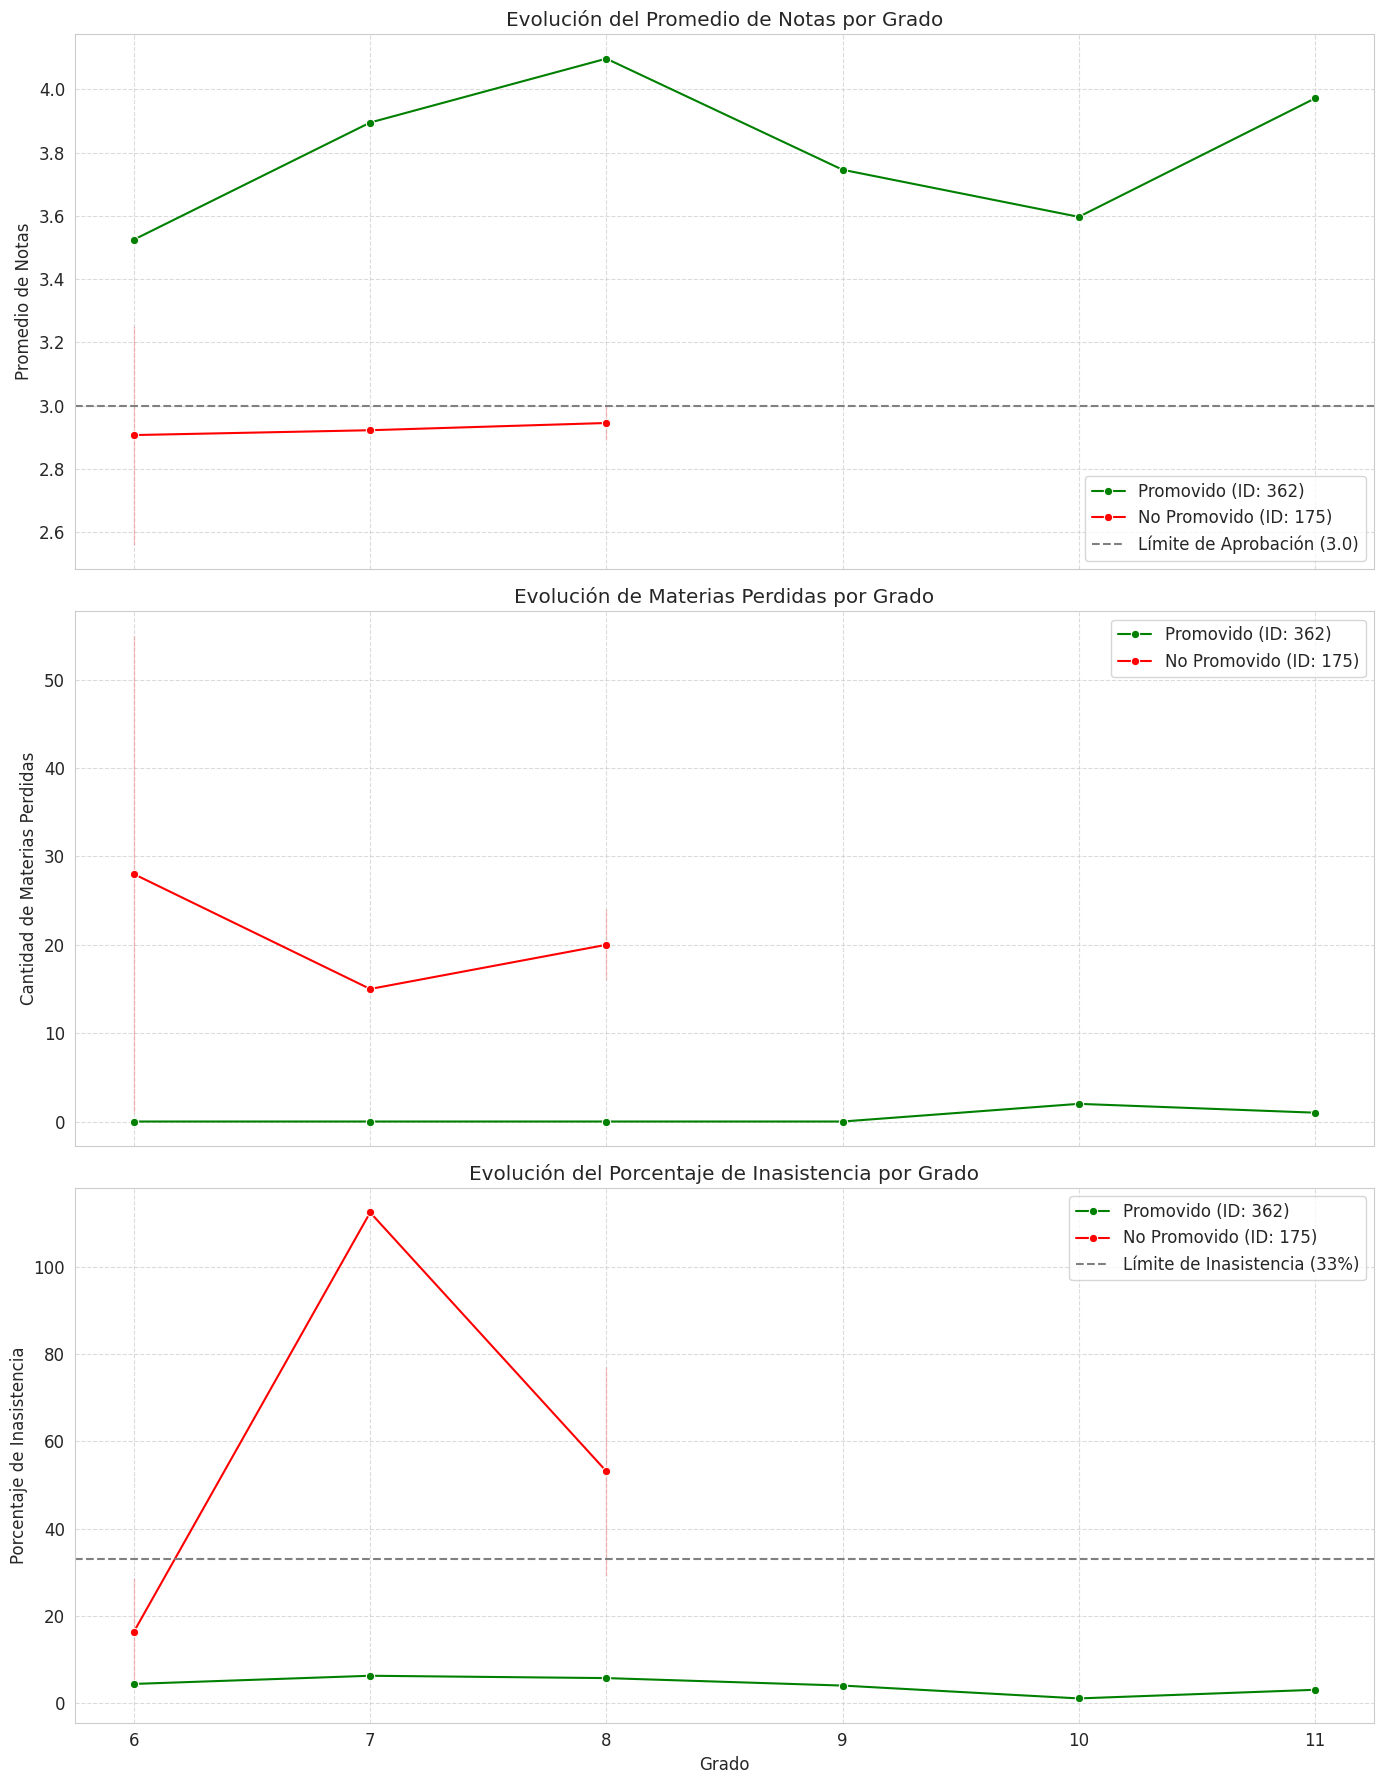

In [26]:
import matplotlib.pyplot as plt
import seaborn as sns

if promoted_student_id is not None and non_promoted_student_id is not None:
    fig, axes = plt.subplots(3, 1, figsize=(14, 18), sharex=True)

    # Promedio de Notas
    sns.lineplot(data=student_promoted_data, x='grado', y='promedio_nota', marker='o', label=f'Promovido (ID: {promoted_student_id})', ax=axes[0], color='green')
    sns.lineplot(data=student_non_promoted_data, x='grado', y='promedio_nota', marker='o', label=f'No Promovido (ID: {non_promoted_student_id})', ax=axes[0], color='red')
    axes[0].axhline(3.0, color='gray', linestyle='--', label='Límite de Aprobación (3.0)')
    axes[0].set_title('Evolución del Promedio de Notas por Grado')
    axes[0].set_ylabel('Promedio de Notas')
    axes[0].legend()
    axes[0].grid(True, linestyle='--', alpha=0.7)

    # Materias Perdidas
    sns.lineplot(data=student_promoted_data, x='grado', y='materias_perdidas', marker='o', label=f'Promovido (ID: {promoted_student_id})', ax=axes[1], color='green')
    sns.lineplot(data=student_non_promoted_data, x='grado', y='materias_perdidas', marker='o', label=f'No Promovido (ID: {non_promoted_student_id})', ax=axes[1], color='red')
    axes[1].set_title('Evolución de Materias Perdidas por Grado')
    axes[1].set_ylabel('Cantidad de Materias Perdidas')
    axes[1].legend()
    axes[1].grid(True, linestyle='--', alpha=0.7)

    # Porcentaje de Inasistencia
    sns.lineplot(data=student_promoted_data, x='grado', y='porc_inasistencia', marker='o', label=f'Promovido (ID: {promoted_student_id})', ax=axes[2], color='green')
    sns.lineplot(data=student_non_promoted_data, x='grado', y='porc_inasistencia', marker='o', label=f'No Promovido (ID: {non_promoted_student_id})', ax=axes[2], color='red')
    axes[2].axhline(33, color='gray', linestyle='--', label='Límite de Inasistencia (33%)')
    axes[2].set_title('Evolución del Porcentaje de Inasistencia por Grado')
    axes[2].set_xlabel('Grado')
    axes[2].set_ylabel('Porcentaje de Inasistencia')
    axes[2].legend()
    axes[2].grid(True, linestyle='--', alpha=0.7)

    plt.tight_layout()
    plt.show()
else:
    print("No se pueden generar gráficos comparativos debido a que no se encontraron estudiantes adecuados.")

### 10.2 Distribución de Notas (Histogramas)

Se analizan las distribuciones generales del promedio de notas para ambos estudiantes a lo largo de su trayectoria.

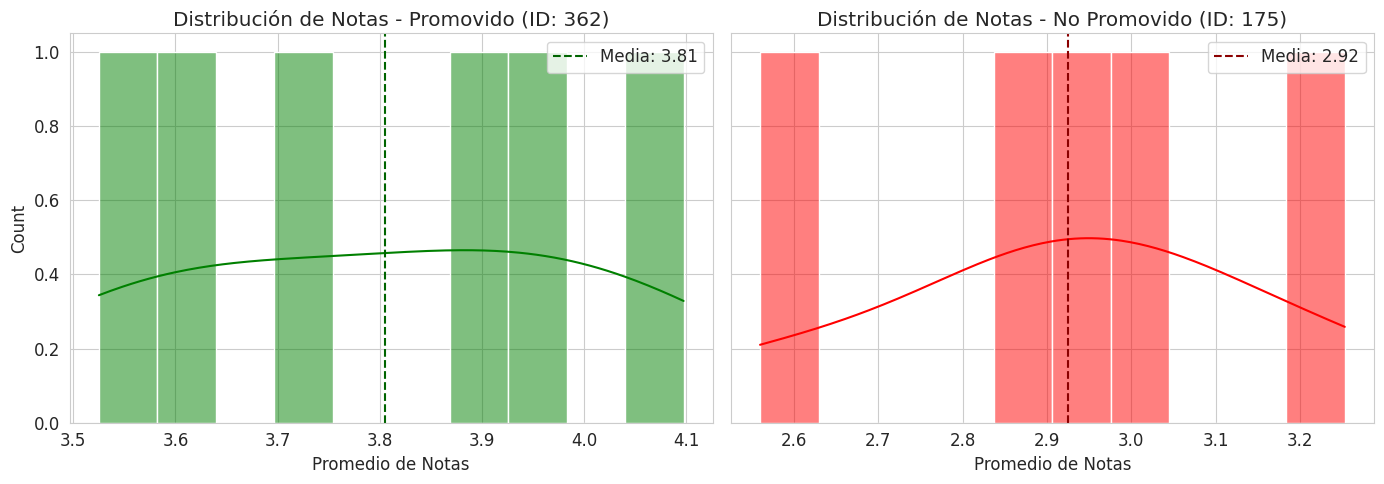

In [27]:
import matplotlib.pyplot as plt
import seaborn as sns

if promoted_student_id is not None and non_promoted_student_id is not None:
    fig, axes = plt.subplots(1, 2, figsize=(14, 5), sharey=True)

    # Histograma para el estudiante Promovido
    sns.histplot(student_promoted_data['promedio_nota'], bins=10, kde=True, ax=axes[0], color='green')
    axes[0].axvline(student_promoted_data['promedio_nota'].mean(), color='darkgreen', linestyle='--', label=f'Media: {student_promoted_data["promedio_nota"].mean():.2f}')
    axes[0].set_title(f'Distribución de Notas - Promovido (ID: {promoted_student_id})')
    axes[0].set_xlabel('Promedio de Notas')
    axes[0].legend()

    # Histograma para el estudiante No Promovido
    sns.histplot(student_non_promoted_data['promedio_nota'], bins=10, kde=True, ax=axes[1], color='red')
    axes[1].axvline(student_non_promoted_data['promedio_nota'].mean(), color='darkred', linestyle='--', label=f'Media: {student_non_promoted_data["promedio_nota"].mean():.2f}')
    axes[1].set_title(f'Distribución de Notas - No Promovido (ID: {non_promoted_id})')
    axes[1].set_xlabel('Promedio de Notas')
    axes[1].legend()

    plt.tight_layout()
    plt.show()
else:
    print("No se pueden generar histogramas comparativos debido a que no se encontraron estudiantes adecuados.")

### 10.3 Conclusiones del Análisis Comparativo

Aquí se interpretan los resultados de la comparación entre los dos estudiantes. Los gráficos de línea muestran cómo el rendimiento (`promedio_nota`), las `materias_perdidas` y la `porc_inasistencia` evolucionan de manera diferente para un estudiante que es promovido consistentemente frente a uno que experimenta dificultades. Los histogramas resaltan las diferencias en la distribución general de sus calificaciones. Este análisis subraya la importancia de la detección temprana de indicadores de riesgo para poder ofrecer intervenciones oportunas.

## Paso 11: Conclusiones del Análisis Exploratorio de Datos (EDA)

El exhaustivo Análisis Exploratorio de Datos ha permitido una comprensión profunda de las características de la población estudiantil y los factores que inciden en su rendimiento académico y tasa de promoción. A continuación, se detallan los hallazgos clave derivados de cada fase del EDA, integrando el análisis de todas las tablas y gráficos generados:

### Hallazgos Principales Detallados y su Impacto

1.  **Distribución del Rendimiento Académico (Análisis Univariado - Sección 4.1)**:
    *   **`promedio_nota`**: La distribución del `promedio_nota` (media ~3.17) revela una concentración significativa de estudiantes entre 3.0 y 4.0, indicando que la mayoría se sitúa por encima del umbral de aprobación. Sin embargo, la presencia de una cola extendida hacia notas bajas, incluyendo valores en 0.0 (visibles en los histogramas, boxplots y violin plots), sugiere un segmento de estudiantes con dificultades severas o evaluaciones incompletas. Esto resalta la necesidad de identificar y apoyar a estos estudiantes en riesgo.

2.  **Tasa de Promoción como Variable Objetivo (Análisis Univariado - Sección 4.2)**:
    *   **`promovido_bin`**: La variable binaria de promoción muestra un desequilibrio de clases con un 74.0% de estudiantes promovidos y un 26.0% no promovidos (como se observa en los gráficos de barras y pastel). Este desbalance es crucial para el modelado predictivo, ya que un modelo ingenuo podría favorecer la clase mayoritaria. Las futuras fases deberán emplear técnicas de balanceo para asegurar la precisión en la predicción de la no promoción, un objetivo crítico de este proyecto.

3.  **Rendimiento y Promoción por Grado (Análisis Univariado - Sección 4.3)**:
    *   El análisis por `grado` (gráficos de estudiantes, promedio de notas y tabla de tasa de promoción) muestra una correlación clara entre el grado y el éxito académico. Los grados 6, 7 y 8 presentan las tasas de promoción más bajas (entre 65.7% y 68.1%) y promedios de notas más cercanos a 3.0, lo que sugiere mayores desafíos en los primeros años de secundaria. En contraste, el grado 11 exhibe un rendimiento y una tasa de promoción excepcionales (94.5%), indicando que los estudiantes que alcanzan este nivel han consolidado un perfil académico sólido. Esta información es vital para diseñar intervenciones específicas por nivel educativo.

4.  **Evolución Anual del Rendimiento (Análisis Univariado - Sección 4.4)**:
    *   Las tendencias anuales (gráficos de línea de promedio de notas y tasa de promoción) revelan un aumento notable en el rendimiento y la promoción durante los años 2020 y 2021. Este fenómeno, posiblemente asociado a adaptaciones educativas durante la pandemia, es un punto de interés para futuros análisis cualitativos. Aunque la cantidad de estudiantes por año se mantuvo relativamente constante, la mejora en estas métricas sugiere un impacto externo significativo.

5.  **Correlaciones y Factores Críticos (Análisis Bivariado - Secciones 5.1, 5.2, 5.3)**:
    *   **Matriz de Correlación**: El heatmap de correlación reveló interdependencias entre variables, indicando posibles multicolinealidades (como entre `grado` y `grupo`).
    *   **Correlaciones con `promedio_nota`**: Variables como `materias_perdidas` (-0.91) y `porc_inasistencia` (-0.36) mostraron las correlaciones negativas más fuertes, confirmándose como los predictores más robustos de bajo rendimiento. Inversamente, los promedios de notas en áreas individuales (`prom_X.`) mostraron fuertes correlaciones positivas con el `promedio_nota` general, lo cual es esperable. Este análisis es fundamental para la selección de características en el modelado.
    *   **Relación Materias Perdidas e Inasistencia**: Los boxplots y scatter plots confirmaron que un mayor número de materias perdidas y un alto porcentaje de inasistencia se asocian directamente con promedios de notas significativamente más bajos. La línea de 33% de inasistencia (un umbral normativo) en el gráfico `Inasistencia vs Promedio` destacó un punto crítico donde el rendimiento tiende a decaer drásticamente.

6.  **Análisis por Grupos y Áreas del Saber (Sección 6.1 y 6.2)**:
    *   **`grupo`**: La tabla `grupo_stats` identificó una variabilidad significativa en el rendimiento entre los `grupos` (cursos). Algunos grupos, como 110200 y 110100, muestran consistentemente promedios de notas y tasas de promoción elevadas, mientras que otros (ej., 60300, 60400) presentan un rendimiento notablemente inferior. Esto subraya la necesidad de un enfoque segmentado en las intervenciones.
    *   **Áreas del Saber**: El boxplot de `Distribucion de Promedios por Area del Saber` reveló diferencias en el rendimiento por materia. Áreas como `Ética/Fil/Rel` (promedio de 3.33) y `Téc y Tecnol` (promedio de 3.30) tienden a promedios más altos y con menor variabilidad, mientras que `Otras` (promedio de 2.99) y `Matematicas` (promedio de 3.01) muestran promedios más cercanos al límite de 3.0 y, en algunos casos, una mayor dispersión. Esta información es valiosa para la mejora curricular y el soporte académico específico por materia, ya que permite identificar las áreas donde los estudiantes demuestran un rendimiento más sólido y aquellas donde podrían enfrentar mayores dificultades.

7.  **Análisis de Cohortes (Sección 7.1, 7.2, 7.3, 7.4 y 7.5)**:
    *   **Cohortes Anuales y de Tres Años**: Los análisis por `cohorte` y `cohorte_3yr` han sido cruciales para identificar tendencias a largo plazo. Se observó una variabilidad considerable en el rendimiento y las tasas de promoción entre cohortes. Los gráficos detallados por `cohorte` y `grado`, así como por `cohorte` y `grupo`, revelan trayectorias de rendimiento específicas. Por ejemplo, algunas cohortes mantienen un alto desempeño a través de los grados, mientras que otras experimentan caídas significativas en grados o grupos específicos. La visualización de tablas de cohortes (Sección 7.5) ha permitido identificar visualmente estos patrones, siendo fundamental para la planificación estratégica y la focalización de recursos.

8.  **Análisis Detallado de la Cohorte 2016-6 (Secciones 7.6.6 y 7.6.7)**:
    *   La investigación profunda de la **cohorte 2016-6** (estudiantes que ingresaron a sexto grado en 2016) hasta su posible graduación reveló patrones específicos en su trayectoria académica y demográfica. A través de la visualización de la evolución del promedio de notas, la tasa de promoción y la distribución de notas en años clave, se pudo observar cómo esta cohorte progresó.
    *   La comparación crítica de la tasa de promoción de la cohorte 2016-6 con el promedio de todas las demás cohortes (`76.49%`) mostró que esta cohorte específica tuvo una tasa de promoción significativamente **menor del 69.68%**. Este hallazgo es un indicador clave de que la cohorte 2016-6 enfrentó mayores desafíos o condiciones menos favorables, lo que justifica una investigación más profunda sobre los factores que pudieron haber contribuido a esta disparidad y la necesidad de intervenciones dirigidas para cohortes futuras con perfiles similares.

9.  **Detección de Valores Atípicos (Outliers) (Sección 8.1 y 8.2)**:
    *   La inspección visual con boxplots y la identificación programática con el método IQR revelaron un número considerable de outliers en variables clave como `promedio_nota`, `total_faltas`, `porc_inasistencia`, `materias_perdidas` y `prom_X.`. Estos outliers representan casos extremos de rendimiento o inasistencia. La gestión adecuada de estos valores (eliminación, transformación o robustez del modelo) será esencial en la fase de preprocesamiento para evitar que distorsionen los resultados del modelado.

10. **Reglas de Negocio vs. Realidad (Análisis de Segmentación - Sección 9.1 y 9.2)**:
    *   La aplicación de los criterios de no promoción basados en la normativa colombiana (`crit_3materias`, `crit_inasistencia`, `crit_promedio`) permitió identificar a 3067 estudiantes en riesgo según estas reglas. Sin embargo, la comparación con la variable de `promovido_bin` real (matriz de confusión) mostró una **coincidencia del 68.4%**. Esto implica que las reglas de negocio, aunque útiles, no son completamente precisas y existe un 31.6% de divergencia entre la predicción normativa y la realidad. Esta brecha establece un **baseline** crucial: cualquier modelo predictivo de Machine Learning deberá superar este porcentaje de coincidencia para demostrar un valor agregado significativo en la identificación temprana de estudiantes en riesgo.

### Implicaciones Estratégicas para el Modelado Predictivo

*   **Manejo del Desbalance de Clases**: El desequilibrio en la variable target (`promovido_bin`) es un factor crítico. Será imperativo aplicar técnicas de balanceo de clases (e.g., SMOTE, oversampling, undersampling) o emplear algoritmos de Machine Learning que sean inherentemente robustos a este problema para evitar que el modelo se sesgue hacia la clase mayoritaria y falle en identificar correctamente a los estudiantes no promovidos.
*   **Selección y Creación de Características (Feature Engineering)**: Las variables identificadas con fuertes correlaciones, como `materias_perdidas`, `porc_inasistencia`, `nota_std` y los promedios por `Áreas del Saber` (`prom_X.`), serán features fundamentales para el modelo. Además, se explorará la creación de nuevas características a partir de las existentes (e.g., ratios, interacciones, variables de rezago temporal si la estructura de datos lo permite) para capturar relaciones más complejas y mejorar el poder predictivo.
*   **Establecimiento de un Baseline Sólido**: El 68.4% de coincidencia entre las reglas de negocio y la promoción real servirá como el rendimiento mínimo que cualquier modelo predictivo debe superar. Este baseline proporciona un punto de referencia claro para evaluar el éxito de los modelos desarrollados, asegurando que las soluciones de Machine Learning aporten un valor real y tangible a la institución educativa en la identificación proactiva de estudiantes en riesgo de no promoción.

### Recursos

*   **Datasets proporcionados**: El análisis se basó en los datasets proporcionados, incluyendo `Resultados_2015-2024_limpio.csv`, que fue fundamental para el mapeo y análisis de las áreas del saber.
*   **Análisis Comparativo de Trayectorias Académicas (Sección 11)**: El estudio de dos estudiantes, uno promovido (ID: 362) y uno no promovido (ID: 175), reveló diferencias marcadas en sus trayectorias académicas. El estudiante promovido mantuvo consistentemente promedios altos, pocas materias perdidas y baja inasistencia. En contraste, el estudiante no promovido mostró promedios más bajos y fluctuantes, mayor cantidad de materias perdidas y altos porcentajes de inasistencia, superando en ocasiones el límite del 33%. Este análisis subraya la importancia de monitorear estas métricas clave para la detección temprana de riesgo y la intervención oportuna.